In the previous experiment we saw that after doing a cv2 resize using INTER_NEAREST or INTER_AREA, the resulting image is less sharp than the original. I need to measure or define sharpness in this context. 

It could be either the size of the border, which I was suspecting before, or the contrast between the border and the two backgrounds. The lighter regions are lighter in the actual distant image, and the darker regions are darker. 

The first thing we do is analyse the border differences. I'll start with largest vs smallest

In [24]:
from pathlib import Path
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass, field
from copy import deepcopy
import itertools
from operator import attrgetter as attrg
import functools
import cv2
import numpy as np

In [25]:

DS = Path("../../../datasets")
BLUR_DS = DS / "blur"
PLASTIC_BAG = BLUR_DS / "imgs-with-distances" / "plastic-bag"

IMG_ROOT = PLASTIC_BAG / "10x4"

In [26]:
import json
import csv
from dataclasses import asdict, fields


@dataclass
class BorderPixels:
    min: int
    max: int
    # this last one is subjective
    most_seen: int


@dataclass
class Result:
    src: Path
    target: Path
    src_dist_r: int
    src_dist_c: int
    target_dist_r: int
    target_dist_c: int
    src_bbox_h: int
    src_bbox_w: int
    target_bbox_h: int
    target_bbox_w: int
    src_horiz_border_pxls: BorderPixels
    src_vert_border_pxls: BorderPixels
    target_horiz_border_pxls: BorderPixels
    target_vert_border_pxls: BorderPixels
    blur_before_k: int
    blur_before_sigma: int
    blur_after_k: int
    blur_after_sigma: int
    comments: str


class ResultGather:
    def __init__(self, out):
        self.out = Path(out)
        self.out.parent.mkdir(exist_ok=True, parents=True)
        self.fieldnames = [f.name for f in fields(Result)]
        if self.out.exists():
            with open(self.out, newline="") as f:
                self.r = list(csv.DictReader(f))
        else:
            self.r = []

    def append(self, r: Result):
        row = asdict(r)
        self.r.append(row)
        write_header = not self.out.exists() or self.out.stat().st_size == 0
        with open(self.out, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.fieldnames)
            if write_header:
                writer.writeheader()
            writer.writerow(row)

In [45]:
from typing import Literal


def resize_h(img, h, interpolation):
    new_height = h
    aspect_ratio = new_height / img.shape[0]
    new_width = int(img.shape[1] * aspect_ratio)
    return cv2.resize(img, (new_width, new_height), interpolation=interpolation)


def resize_w(img, w, interpolation):
    new_width = w
    aspect_ratio = new_width / img.shape[1]
    new_height = int(img.shape[0] * aspect_ratio)
    return cv2.resize(img, (new_width, new_height), interpolation=interpolation)


def _get_tlrb(img, bb):
    t, l = bb.y0, bb.x0
    b, r = img.shape[0] - bb.y1, img.shape[1] - bb.x1
    return t, l, r, b


def _resize_gemini(img, new_height, new_width, scale_factor):
    img_float = img.astype(np.float32) / 255.0
    img_linear = np.power(img_float, 2.2)

    # 2. Apply the "Physics" (Blur + Resize)
    # The sigma should be calculated to prevent aliasing based on the scale factor
    sigma = 0.5 * (1 / scale_factor) 
    blurred = cv2.GaussianBlur(img_linear, (0, 0), sigmaX=sigma)
    resized_linear = cv2.resize(blurred, (new_width, new_height), interpolation=cv2.INTER_AREA)

    # 3. Re-apply Gamma and convert back to 8-bit
    img_res_float = np.power(resized_linear, 1.0/2.2)
    return (np.clip(img_res_float, 0, 1) * 255).astype(np.uint8)


def resize_gemini_w(img, w, scale_factor):
    # 1. Convert to float and Linearize (Gamma 2.2)
    new_width = w
    aspect_ratio = new_width / img.shape[1]
    new_height = int(img.shape[0] * aspect_ratio)
    return _resize_gemini(img, new_height, new_width, scale_factor)

def resize_gemini_h(img, h, scale_factor):
    # 1. Convert to float and Linearize (Gamma 2.2)
    new_height = h
    aspect_ratio = new_height / img.shape[0]
    new_width = int(img.shape[1] * aspect_ratio)
    return _resize_gemini(img, new_height, new_width, scale_factor)

# The standard resize when run on the first example of hit bug sprays was not enough.
# The standard resize works on the entire image.
# So I’ve been taking random crops of images and passing them to resize.
# The new algorithm gets the bounding box of each object and
# finds the dimensions of the source object's crop that need to be resized
# to match the target crop's shape.
# For this, I would just find the resize ratio for the actual bounding boxes. We are using the width here for resizing.
# Then we find how much padding we need in the source box, which depends on the padding in the target image and the resizing padding.
# Once we have that, we get the crop that needs to be resized to the target image size.
# We resize that crop using standard CV2 resize, preserving the aspect ratio between the source and target crops.
def resize_with_bboxes(
    src, src_bbox, target, target_bbox, interpolation, resize_by: Literal["h", "w"]
):
    # the bounded box in src is resized to bounded box in target
    alpha = target_bbox.w / src_bbox.w
    t, l, r, b = _get_tlrb(target, target_bbox)
    t1, l1, r1, b1 = t / alpha, l / alpha, r / alpha, b / alpha

    y0 = int(max(src_bbox.y0 - t1, 0))
    x0 = int(max(src_bbox.x0 - l1, 0))
    y1 = int(min(src_bbox.y1 + b1, src.shape[0]))
    x1 = int(min(src_bbox.x1 + r1, src.shape[1]))

    crop_to_resize = src[y0:y1, x0:x1]
    print("will resize shape", crop_to_resize.shape, "to", target.shape)

    if resize_by == "w":
        return resize_gemini_w(crop_to_resize, target.shape[1], 1)
        # return resize_w(crop_to_resize, target.shape[1], interpolation)
    else:
        return resize_gemini_h(crop_to_resize, target.shape[0], 1)
        # return resize_h(crop_to_resize, target.shape[0], interpolation)


def add_luminosity_lab(rgb, add_constant):
    lab_rsz = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    lab_rsz[:, :, 0] = np.clip(
        lab_rsz[:, :, 0].astype(np.int16) + add_constant, 0, 255
    ).astype(np.uint8)
    return cv2.cvtColor(lab_rsz, cv2.COLOR_LAB2RGB)


def show(crops, figsize=None, ncols=2, cmap=None):
    crops = list(crops)
    crops = [c.rgb if isinstance(c, ImageAndDist) else c for c in crops]
    rows = math.ceil(len(crops) / ncols)
    if figsize is None:
        figsize = (10 * rows, 10 * rows)
        print("figsize", figsize)
    _, axs = plt.subplots(rows, ncols, figsize=figsize)
    try:
        axs[0]
        axs = axs.flatten()
    except:
        axs = [axs]

    for i, c in enumerate(crops):
        if cmap is None:
            axs[i].imshow(c)
        else:
            axs[i].imshow(c, cmap=cmap)
    plt.tight_layout()
    plt.show()


def sobel(img_rgb):
    # Load the image in grayscale
    # Compute the 1st order Sobel derivative in X-direction
    # ddepth is set to cv2.CV_64F to handle negative gradient values
    img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

    # Compute the 1st order Sobel derivative in Y-direction
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Compute the magnitude of the gradient (optional, for combined edge strength)
    # The gradient magnitude is calculated as sqrt(sobelx^2 + sobely^2)
    grad_magnitude = np.sqrt(sobelx**2 + sobely**2)

    # Convert results back to 8-bit image for display
    # Taking absolute values is important before converting to uint8
    return (
        cv2.convertScaleAbs(sobelx),
        cv2.convertScaleAbs(sobely),
        cv2.convertScaleAbs(grad_magnitude),
    )

def overlay_edges(img_rgb, edges, alpha=0.5):
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    return cv2.addWeighted(img_rgb, 1 - alpha, edges_rgb, alpha, 0)


def compose2(f, g):
    return lambda *a, **kw: f(g(*a, **kw))


def compose(*fs):
    return functools.reduce(compose2, fs)


def pipe(*fs):
    fs = reversed(fs)
    return functools.reduce(compose2, fs)


def mapl(f, lst):
    return list(map(f, lst))


def image_distance_sorter_key(img):
    return int(img.stem.split("x")[0])


def coord_from_path(path):
    comps = path.stem.split("x")
    y, x = comps[0], comps[1]
    return int(y), int(x)


@dataclass
class Coord:
    x: int
    y: int

    @classmethod
    def from_path(cls, path: Path) -> "Coord":
        comps = path.stem.split("x")
        y, x = comps[0], comps[1]
        return cls(y=int(y), x=int(x))


@dataclass
class BBox:
    y0: int
    y1: int
    x0: int
    x1: int

    @property
    def h(self):
        return self.y1 - self.y0

    @property
    def w(self):
        return self.x1 - self.x0


@dataclass
class ImageAndDist:
    us: Coord
    root: Coord
    path: Path
    rgb: np.ndarray

    @classmethod
    def from_path(cls, us, root, path):
        return ImageAndDist(us, root, path, plt.imread(path))

    def __getitem__(self, idx):
        if isinstance(idx, BBox):
            rgb = self.rgb[idx.y0 : idx.y1, idx.x0 : idx.x1]
        else:
            rgb = self.rgb[idx]
        return ImageAndDist(self.us, self.root, self.path, rgb)

    def resized_w(self, w, interpolation):
        rgb = resize_w(self.rgb, w, interpolation)
        return ImageAndDist(self.us, self.root, self.path, rgb)

    def resized_h(self, h, interpolation):
        rgb = resize_h(self.rgb, h, interpolation)
        return ImageAndDist(self.us, self.root, self.path, rgb)

    def resized_to_another(self, our_bbox, other, other_bbox, interpolation, resize_by):
        res = resize_with_bboxes(
            self.rgb, our_bbox, other.rgb, other_bbox, interpolation, resize_by
        )
        return self.clone_with_diff_rgb(self, res)

    @property
    def shape(self):
        return self.rgb.shape

    @classmethod
    def clone_with_diff_rgb(cls, src, rgb) -> "ImageAndDist":
        return cls(src.us, src.root, src.path, rgb)

    @classmethod
    def to_res_params_src(cls, src):
        return {
            "src_path": src.path,
            "src_dist_r": src.us.y,
            "src_dist_c": src.us.x,
        }

    @classmethod
    def to_res_params_target(cls, target):
        return {
            "target_path": target.path,
            "target_dist_r": target.us.y,
            "target_dist_c": target.us.x,
        }

    def sobel(self) -> 'ImageAndDist':
        return self.clone_with_diff_rgb(self, sobel(self.rgb)[2])


def rgbs(image_and_dists):
    return map(attrg("rgb"), image_and_dists)

In [46]:
ROOT = Coord.from_path(IMG_ROOT)
closeup = ImageAndDist.from_path(
    us=deepcopy(ROOT), root=deepcopy(ROOT), path=IMG_ROOT / "closeup.jpeg"
)
COL = "x4"
gather = ResultGather(f"./blur_results/{IMG_ROOT.stem}_{COL}.csv")
x4_images = IMG_ROOT.glob(f"*{COL}.jpeg")
x4_images = sorted(x4_images, key=image_distance_sorter_key)
x4_images = [
    ImageAndDist.from_path(root=ROOT, path=p, us=Coord.from_path(p)) for p in x4_images
]

# (14x4) -> (34x4)

figsize (10, 10)


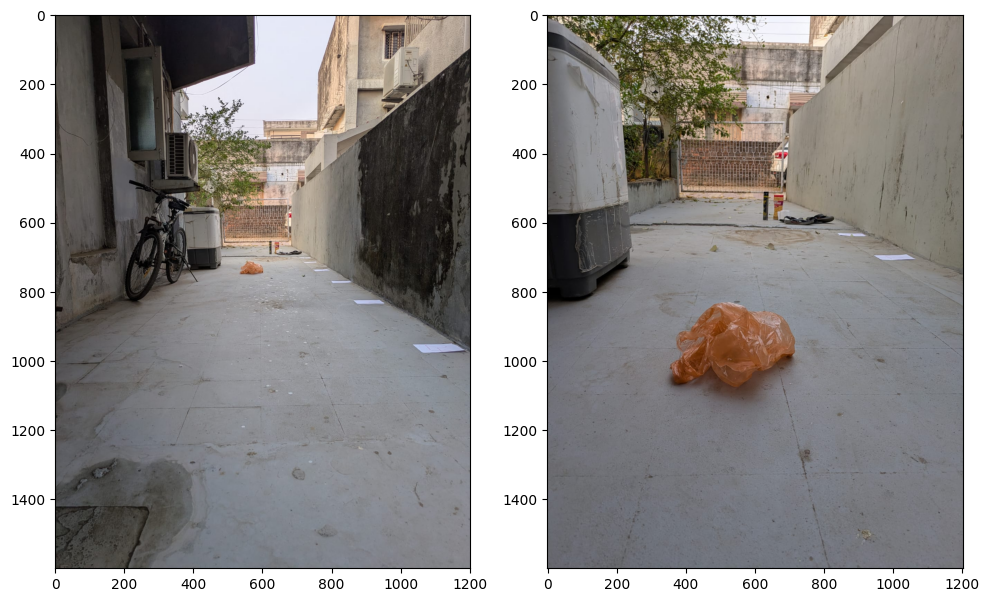

In [29]:
c = x4_images[0]
x = x4_images[4]

show([x, c])

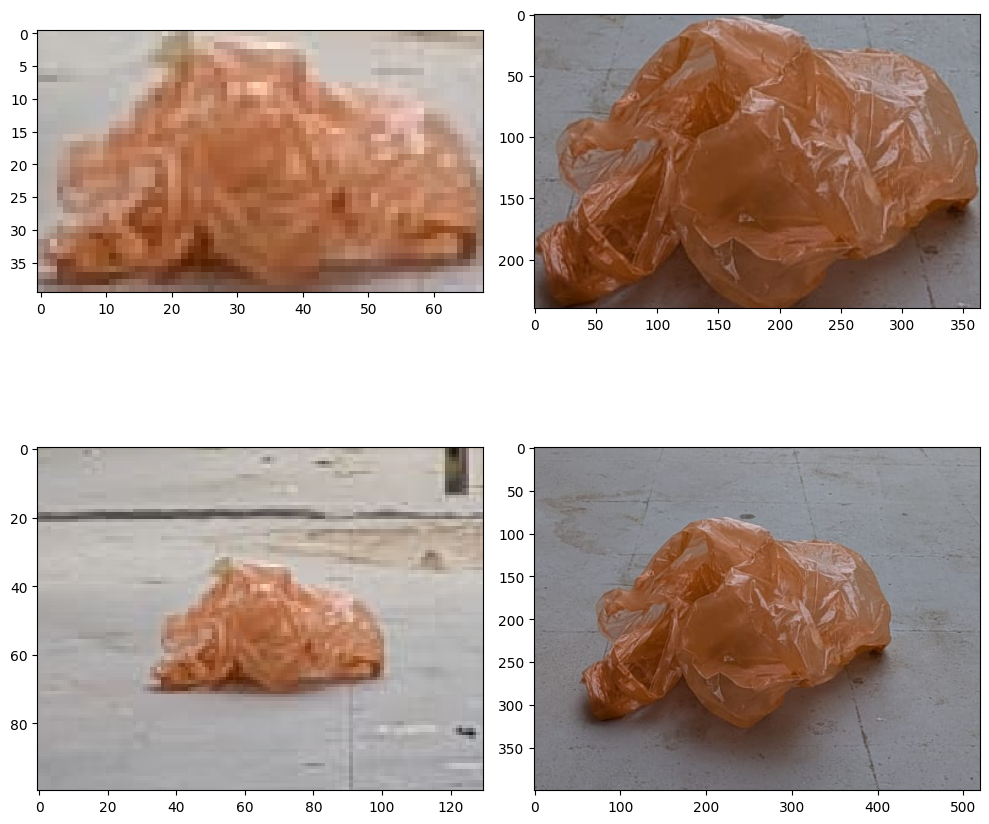

In [30]:
near = c[750:1150, 300:820]
near_bbox = BBox(y0=80, y1=320, x0=54, x1=418)
far = x[680:780, 500:630]
far_bbox = BBox(y0=32, y1=72, x0=33, x1=101)

# show([far, near], (10, 10), ncols=2)
# print(far[far_bbox].shape, near[near_bbox].shape)
show([far[far_bbox], near[near_bbox], far, near], (10, 10), ncols=2)
# show([near[near_bbox], near, far], ncols=3)

In [31]:
near_bbox.h / far_bbox.h

6.0

will resize shape (400, 520, 3) to (100, 130, 3)
will resize shape (400, 520, 3) to (100, 130, 3)
will resize shape (400, 520, 3) to (100, 130, 3)


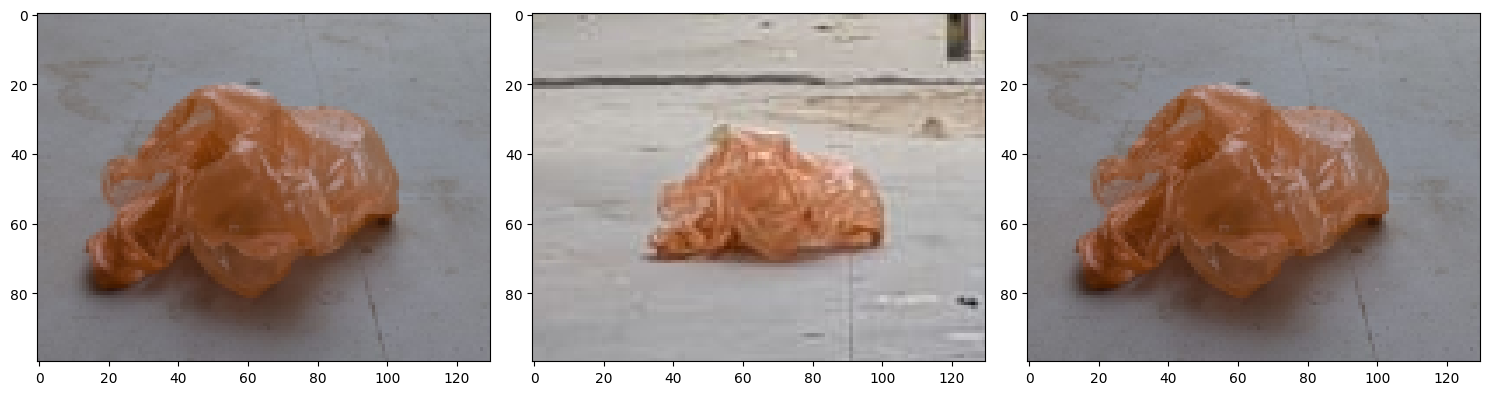

In [32]:
near_rsz = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_AREA, "w")

blurred = ImageAndDist.clone_with_diff_rgb(near, cv2.GaussianBlur(near.rgb, (3,3), 1, sigmaY=1))
blurred_near_rsz_nearest = blurred.resized_to_another(
    near_bbox, far, far_bbox, cv2.INTER_NEAREST, "w"
)
near_rsz_nearest = near.resized_to_another(
    near_bbox, far, far_bbox, cv2.INTER_NEAREST, "w"
)
show([blurred_near_rsz_nearest, far, near_rsz], (15,15), ncols=3)

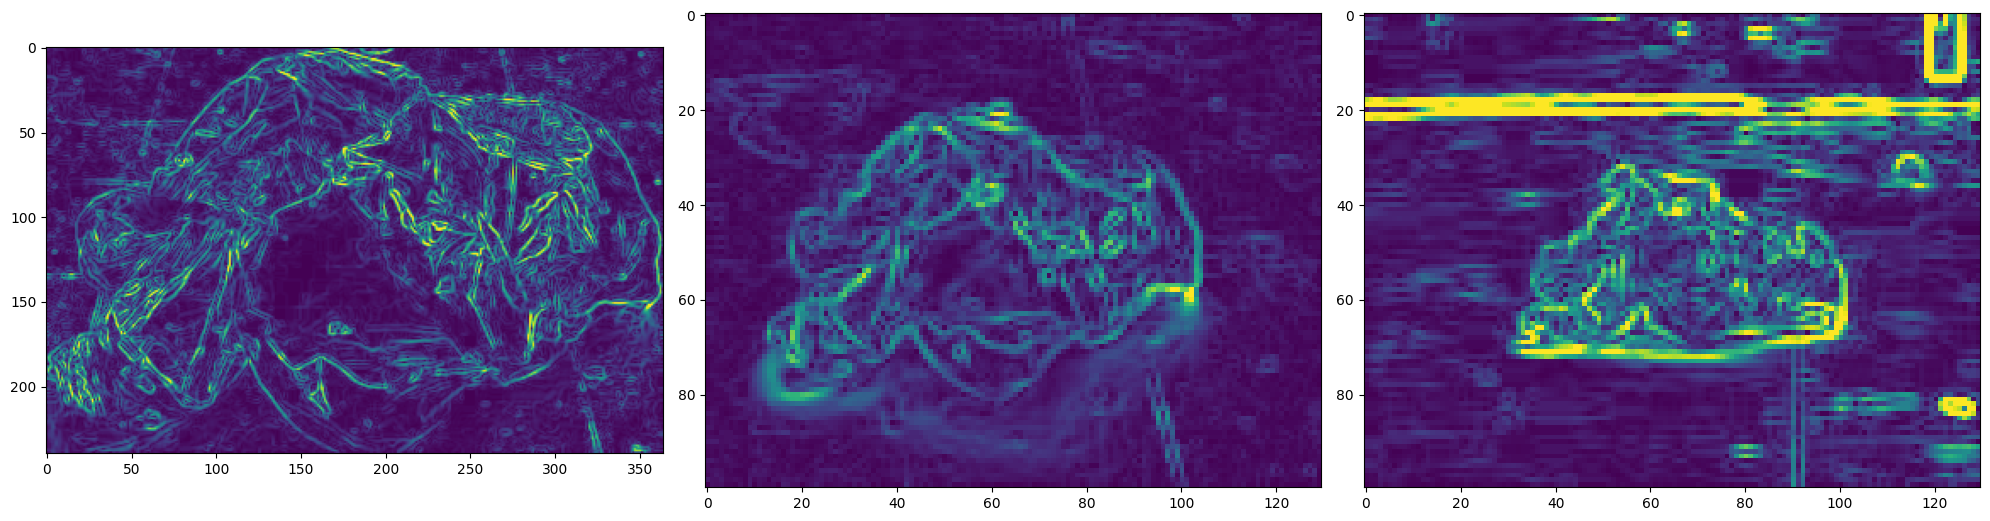

In [33]:
show([
    near[near_bbox].sobel(), blurred_near_rsz_nearest.sobel(), far.sobel()
], (20,20), 3)

In [34]:
np.max(near[near_bbox].rgb), np.max(near_rsz_nearest.rgb), np.max(far[far_bbox].rgb)

(np.uint8(231), np.uint8(205), np.uint8(255))

The edges are already more "pronounced" in the right photo,  I'll need to see how the color comes though

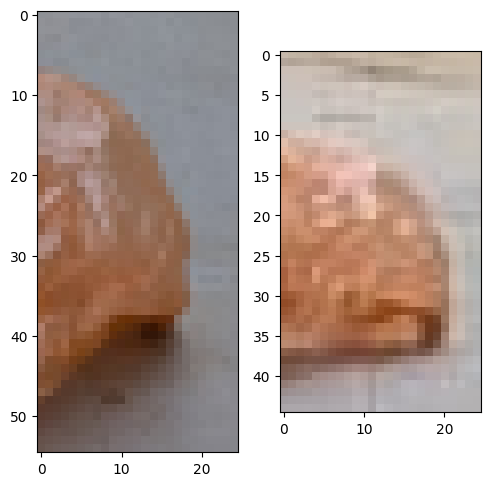

In [35]:
near_edge = near_rsz[20:75, 85:110]
far_edge = far[30:75, 80:105]
show([near_edge, far_edge], figsize=(5,5))

In [29]:
near_edge[20].shape

(25, 3)

In [13]:
near_rsz.shape

(100, 130, 3)

In [14]:
near_edge.shape, far_edge.shape

((55, 25, 3), (45, 25, 3))

figsize (10, 10)


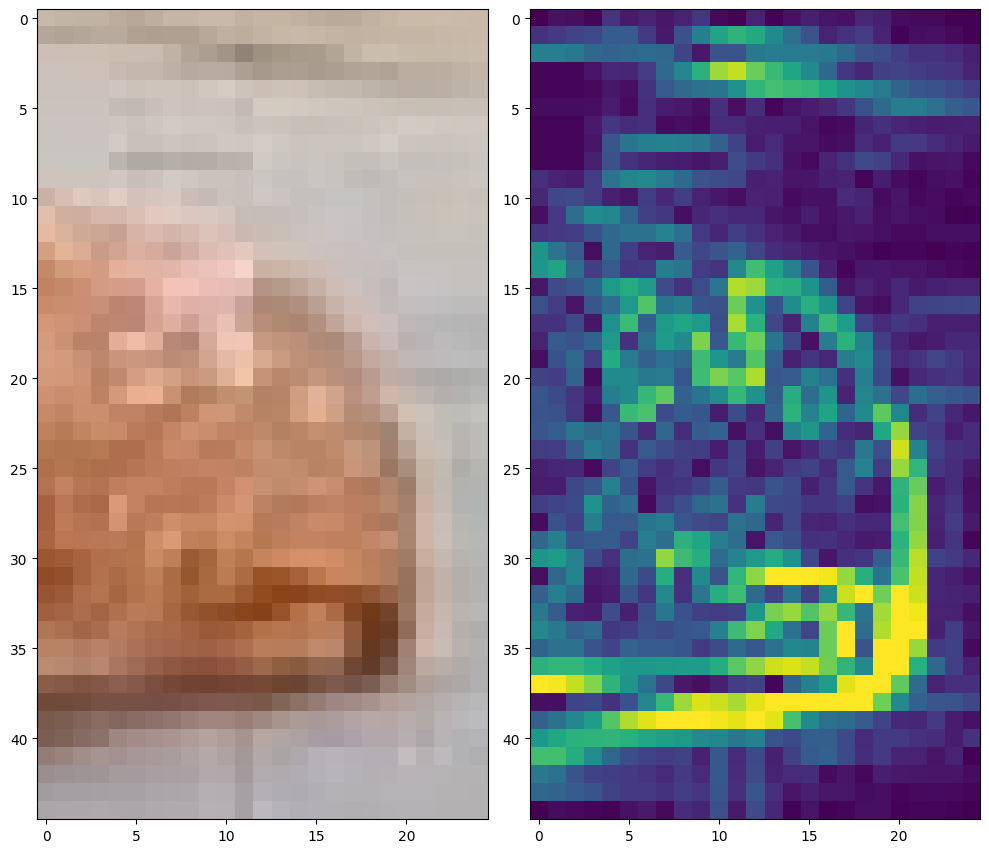

In [36]:
show([far_edge.rgb, sobel(far_edge.rgb)[2]])

figsize (10, 10)


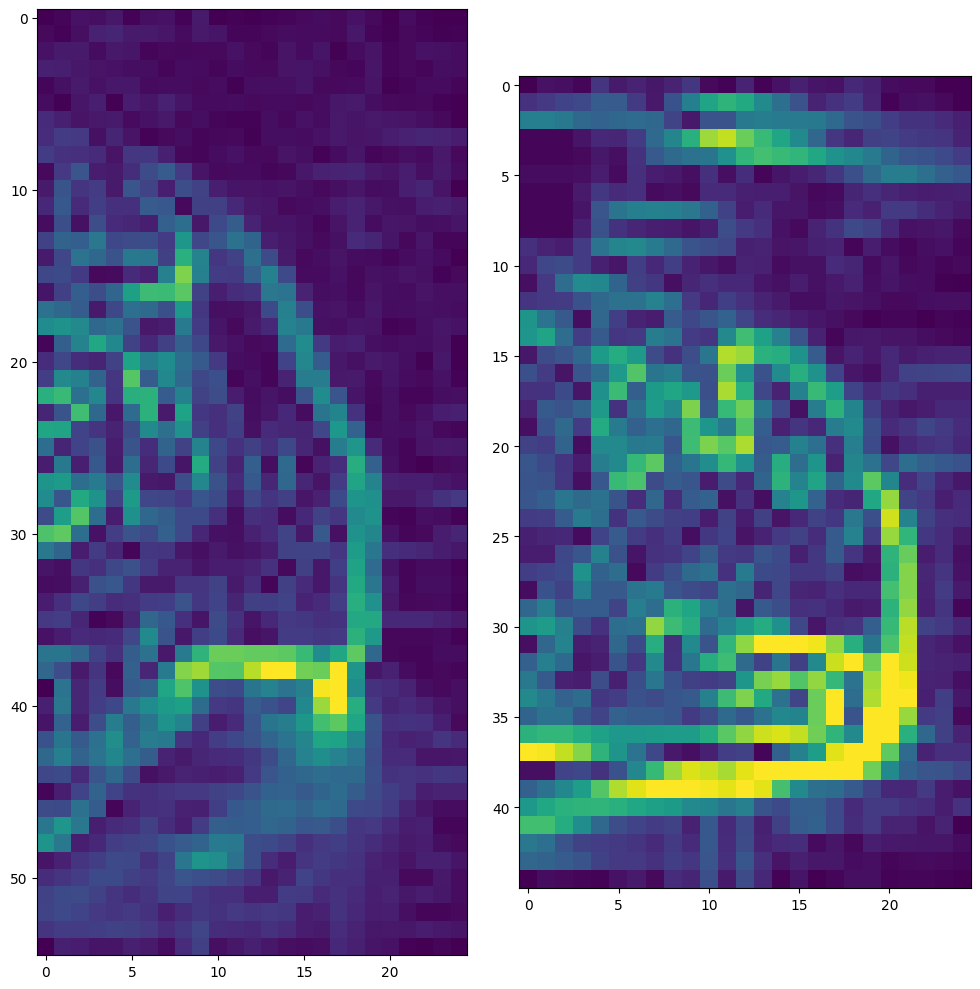

In [16]:
show([sobel(near_edge.rgb)[2], sobel(far_edge.rgb)[2]])

# 29x4 -> 34x4

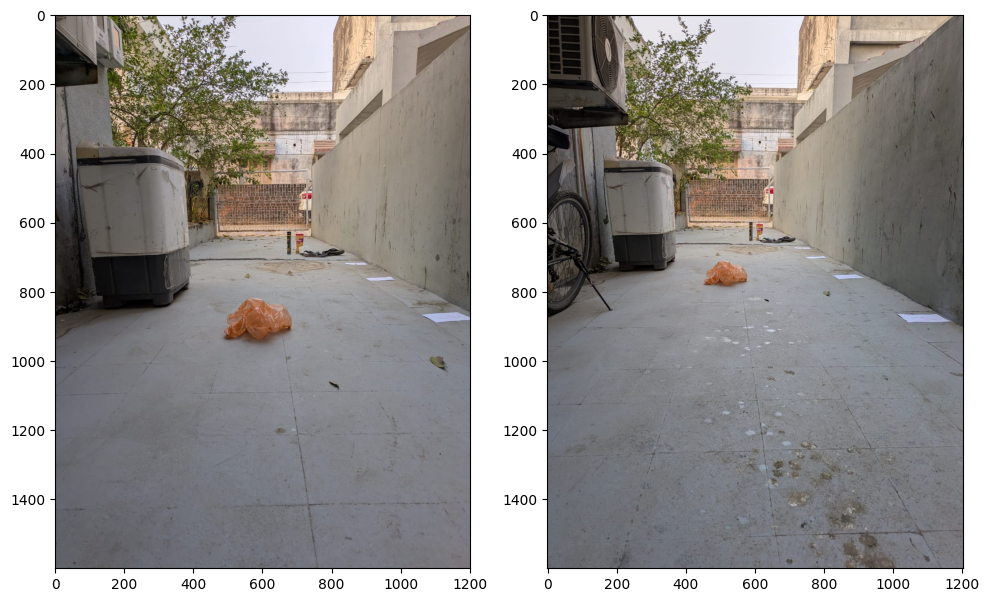

In [47]:
c = x4_images[1]
x = x4_images[2]

show([c, x], figsize=(10, 10))

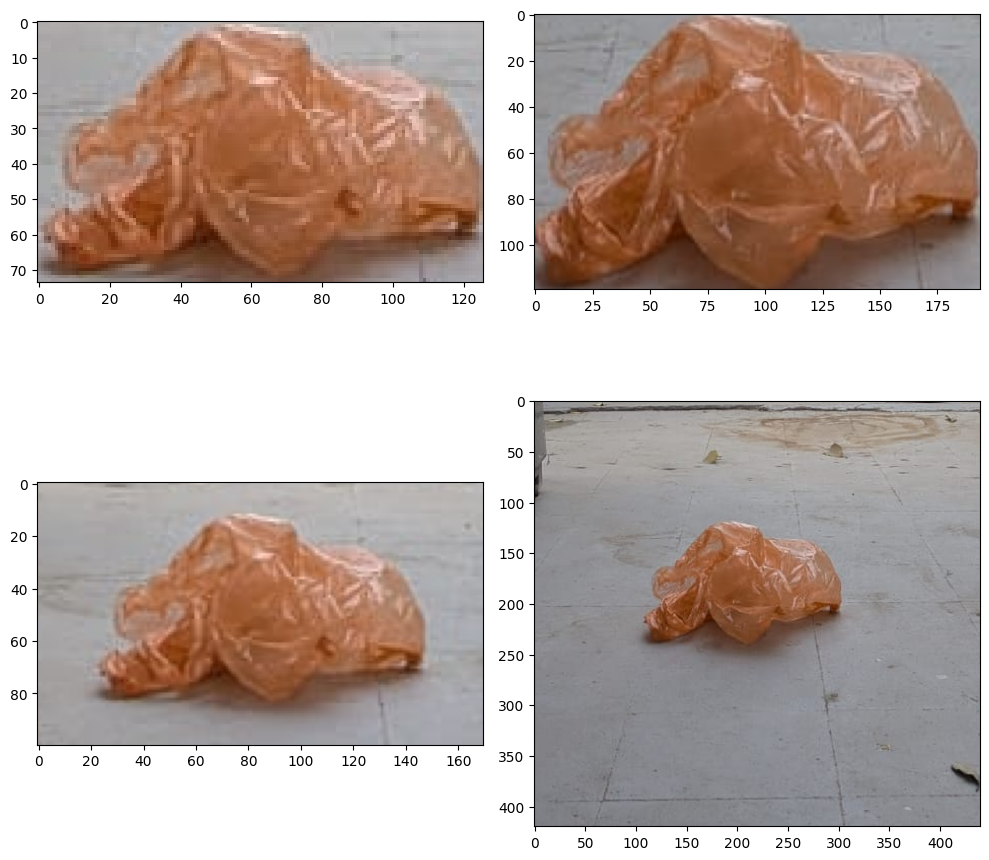

In [48]:
near = c[700:1120, 380:820]
near_bbox = BBox(y0=120, y1=240, x0=110, x1=304)
far = x[700:800, 430:600]
far_bbox = BBox(y0=11, y1=85, x0=22, x1=148)


show([far[far_bbox], near[near_bbox], far, near], (10, 10), ncols=2)
# show([near[near_bbox], near, far], ncols=3)

will resize shape (160, 261, 3) to (100, 170, 3)
will resize shape (160, 261, 3) to (100, 170, 3)
will resize shape (160, 261, 3) to (100, 170, 3)
figsize (30, 30)


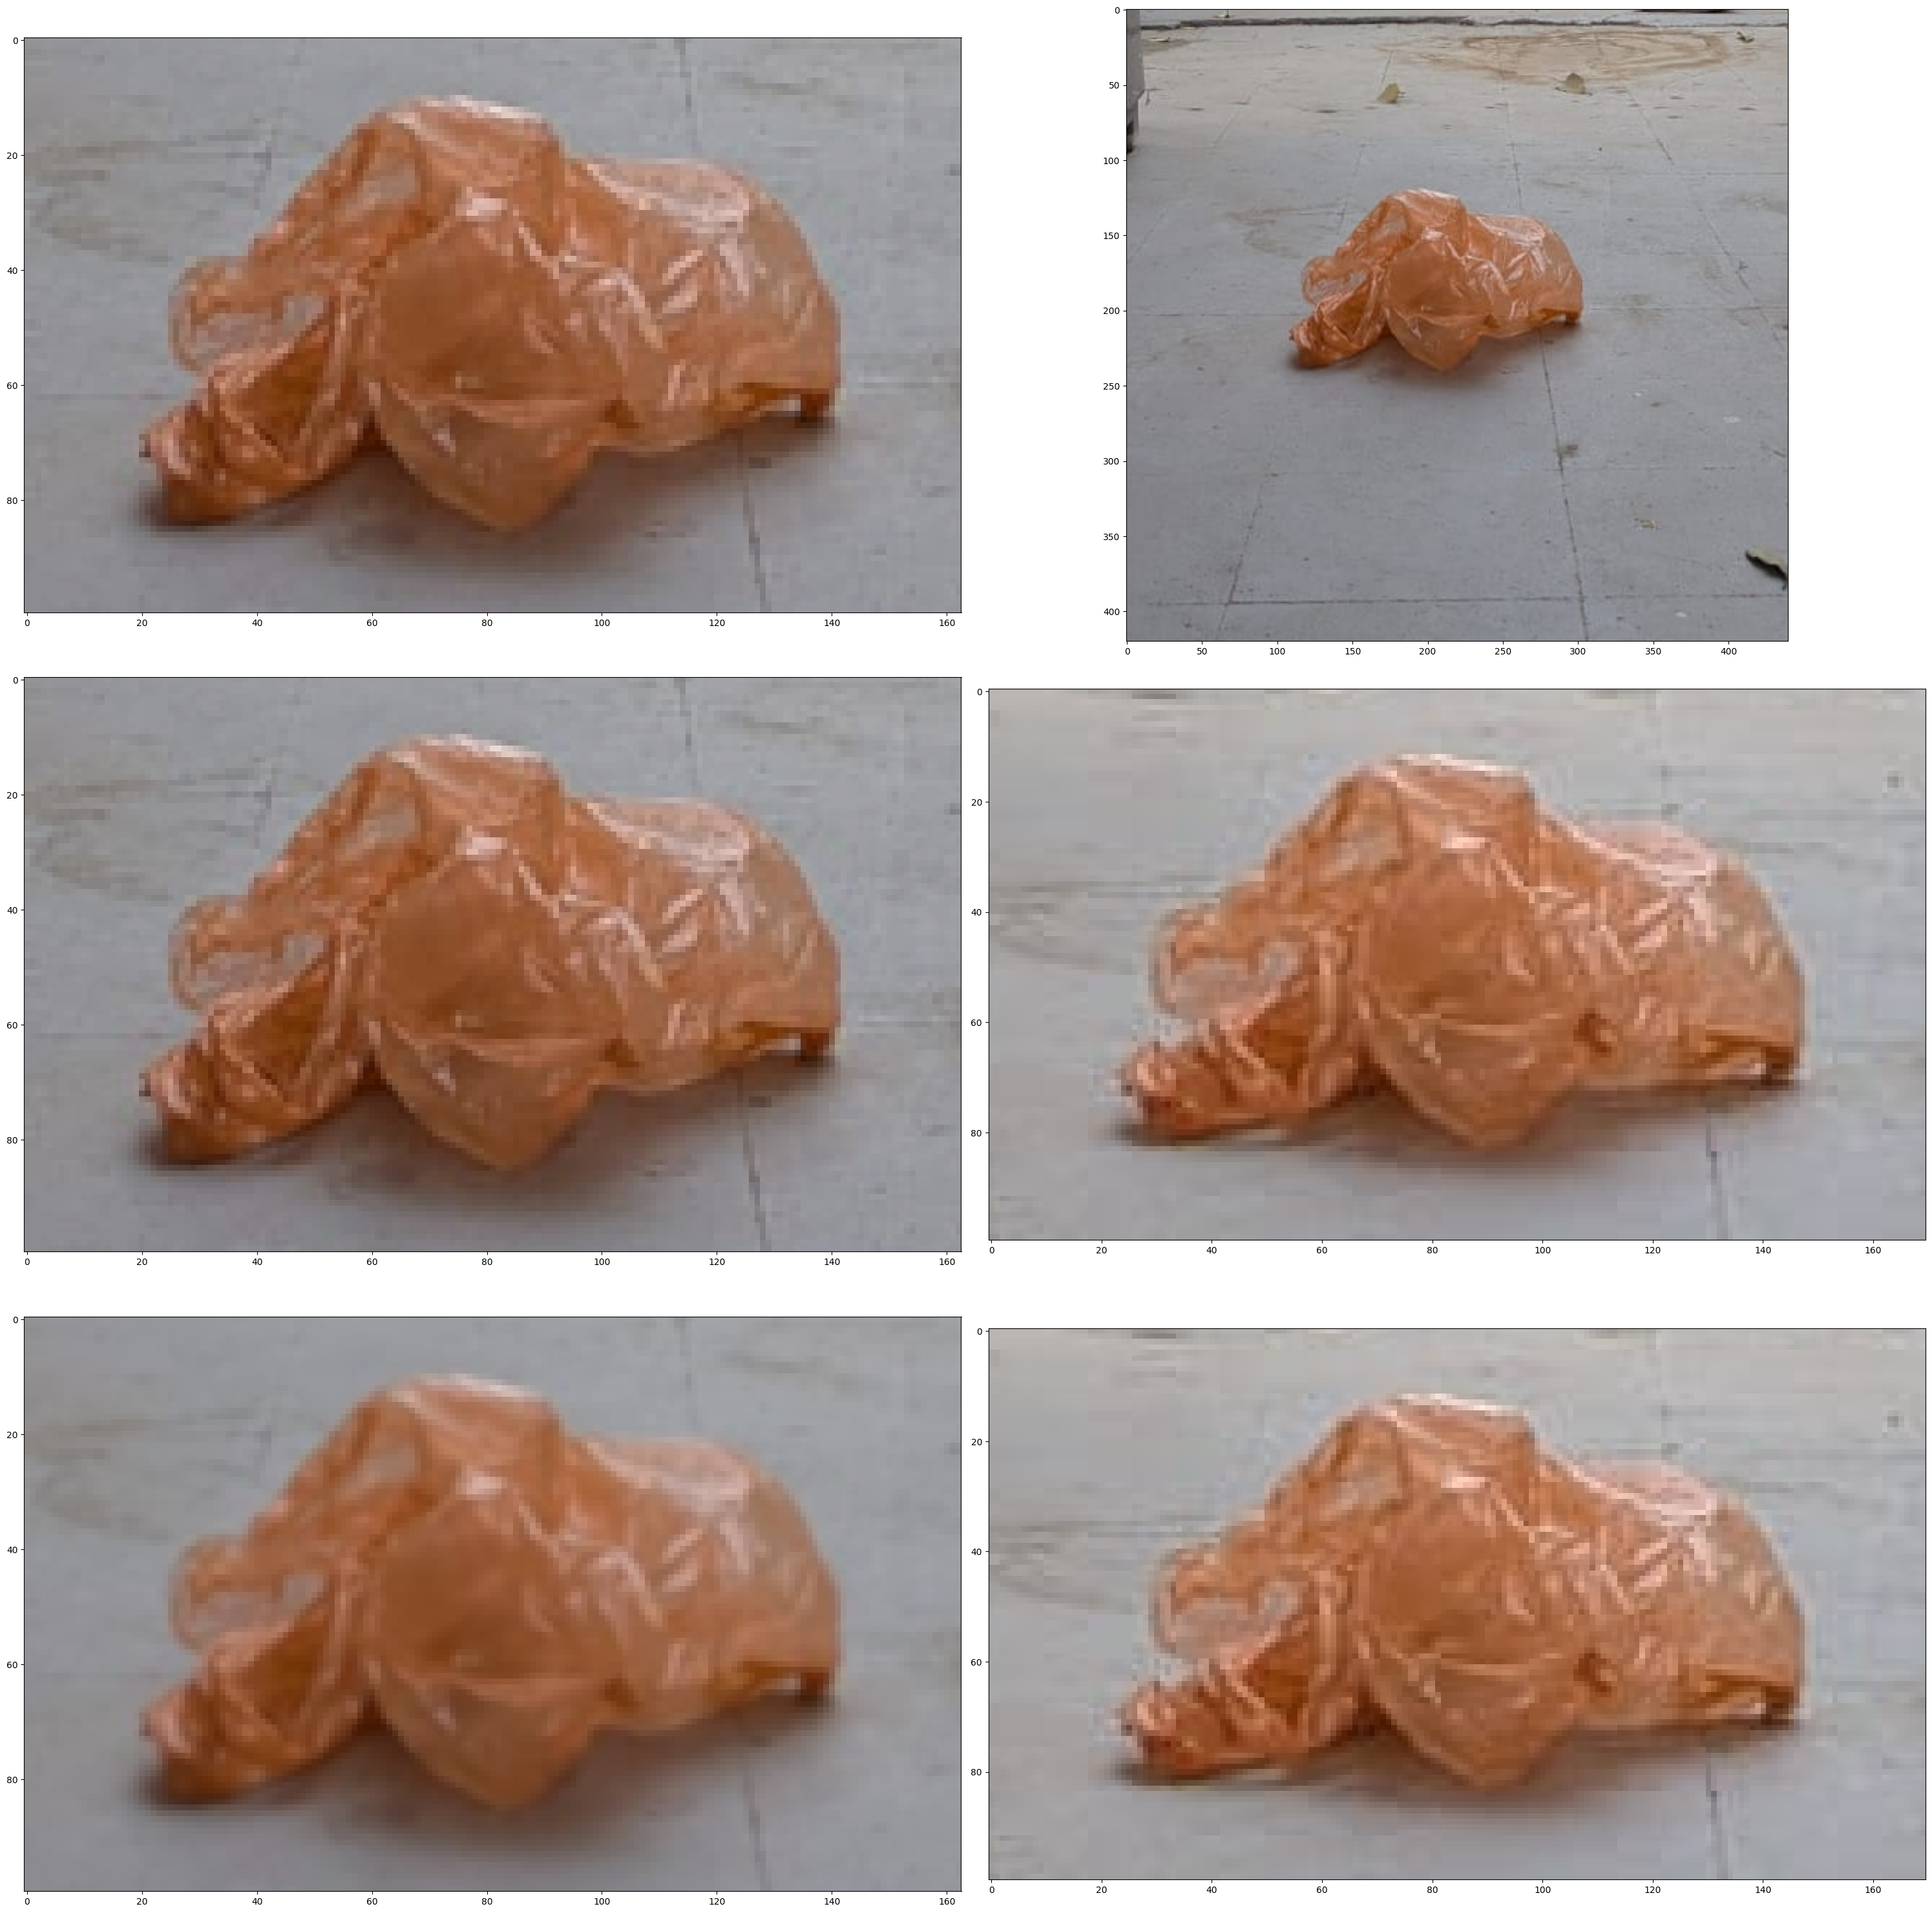

In [49]:
# near_rsz = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_AREA, "h")

near_rsz_orig = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_AREA, "h")

blurred_near = ImageAndDist.clone_with_diff_rgb(
    near, cv2.GaussianBlur(near.rgb, (3,3), 1, sigmaY=1)
)
blurred_rsz = blurred_near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_NEAREST, "h")

near_rsz = near_rsz_orig.rgb
blur = cv2.GaussianBlur(near_rsz, (0,0), 1.0)
sharpened = cv2.addWeighted(near_rsz, 1.5, blur, -0.5, 0)
near_rsz = ImageAndDist.clone_with_diff_rgb(near_rsz_orig, sharpened)

near_rsz_area = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_AREA, "h")
show([near_rsz, near, near_rsz, far, blurred_rsz, far])

In [50]:
near_bbox.h / far_bbox.h

1.6216216216216217

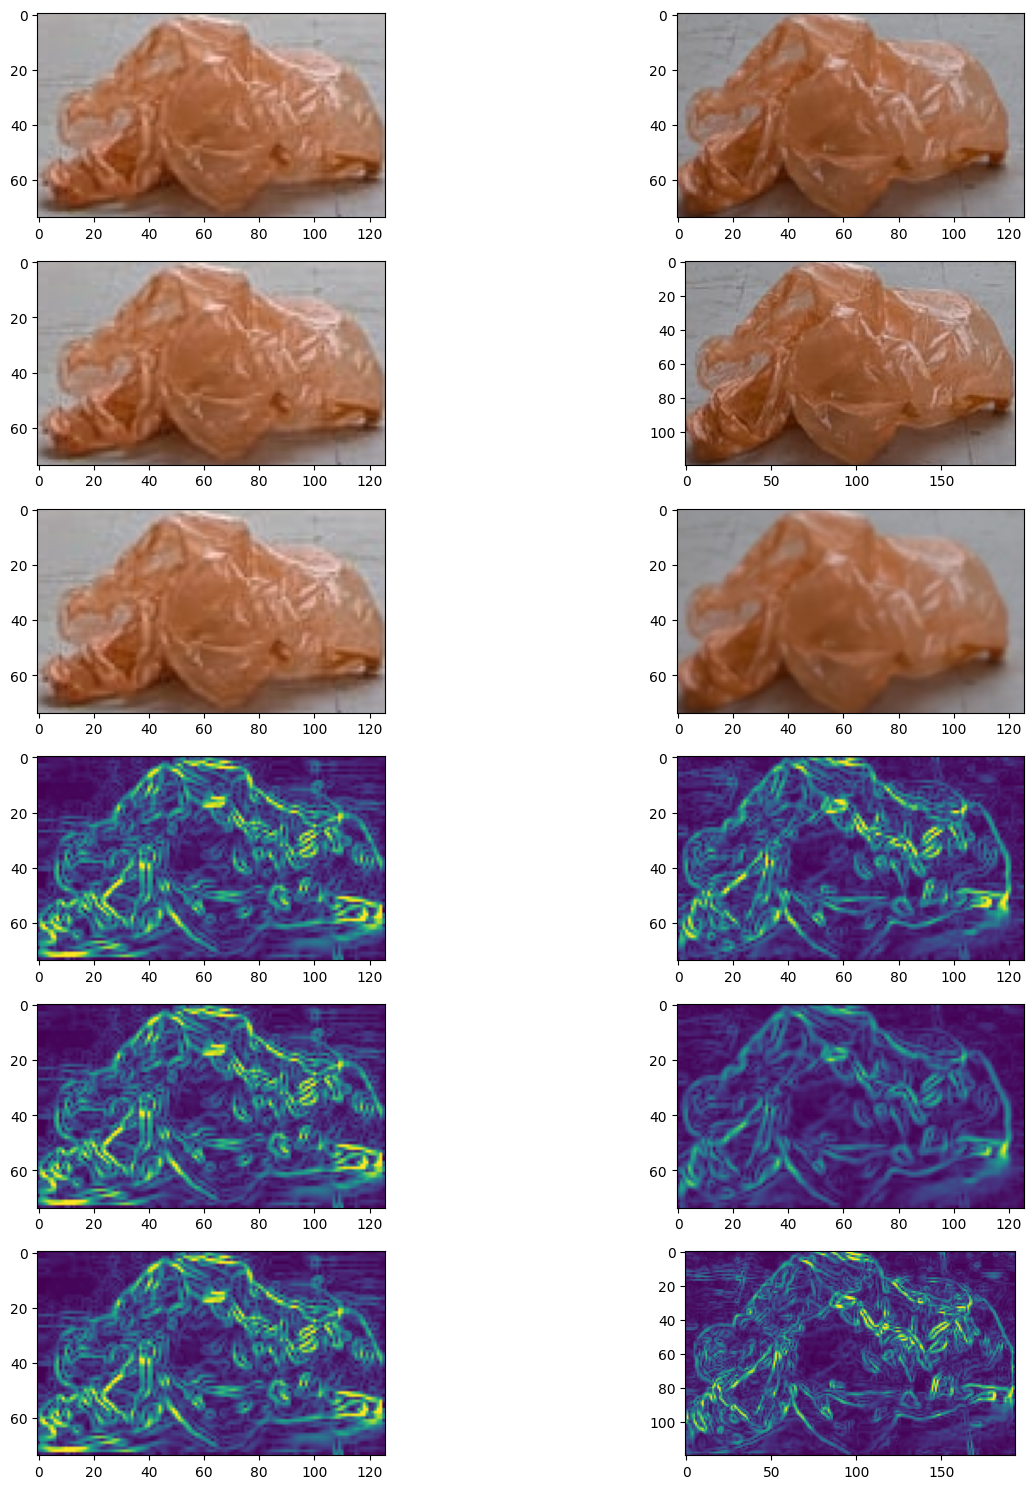

In [51]:
show([
    far[far_bbox], near_rsz[far_bbox],
    far[far_bbox], near[near_bbox],
    far[far_bbox], blurred_rsz[far_bbox],
    sobel(far[far_bbox].rgb)[2], sobel(near_rsz[far_bbox].rgb)[2],
    sobel(far[far_bbox].rgb)[2], sobel(blurred_rsz[far_bbox].rgb)[2],
    sobel(far[far_bbox].rgb)[2], sobel(near[near_bbox].rgb)[2]
], (15,15))

In [49]:
from skimage.exposure import match_histograms


matched = match_histograms(near_rsz_area[far_bbox].rgb, far[far_bbox].rgb, channel_axis=-1)

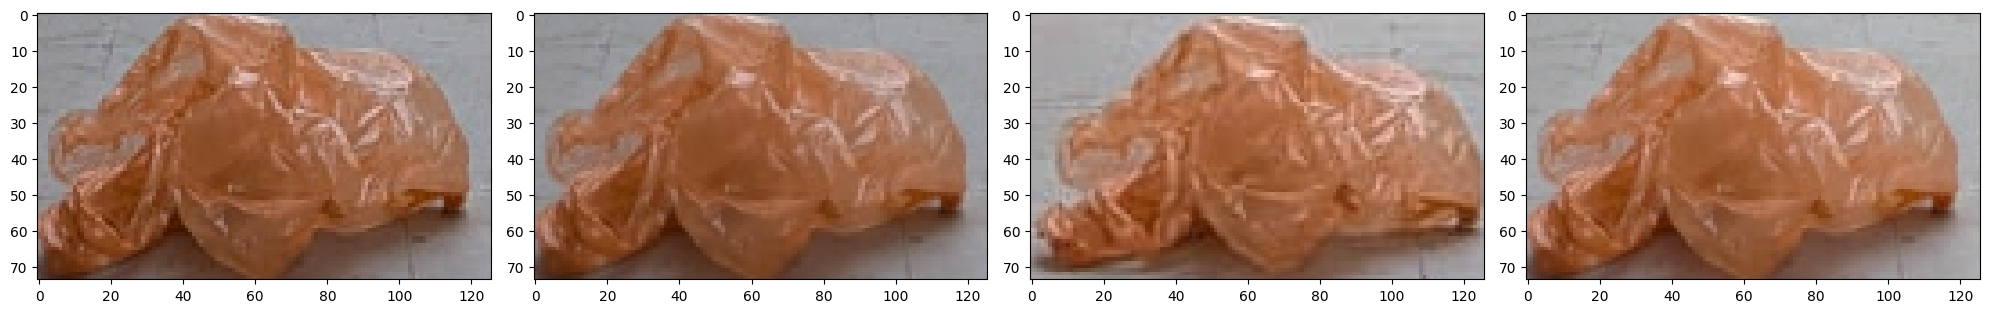

In [51]:
show([
    near_rsz[far_bbox], near_rsz_area[far_bbox], far[far_bbox], matched
], (20,20), ncols=4)

figsize (20, 20)


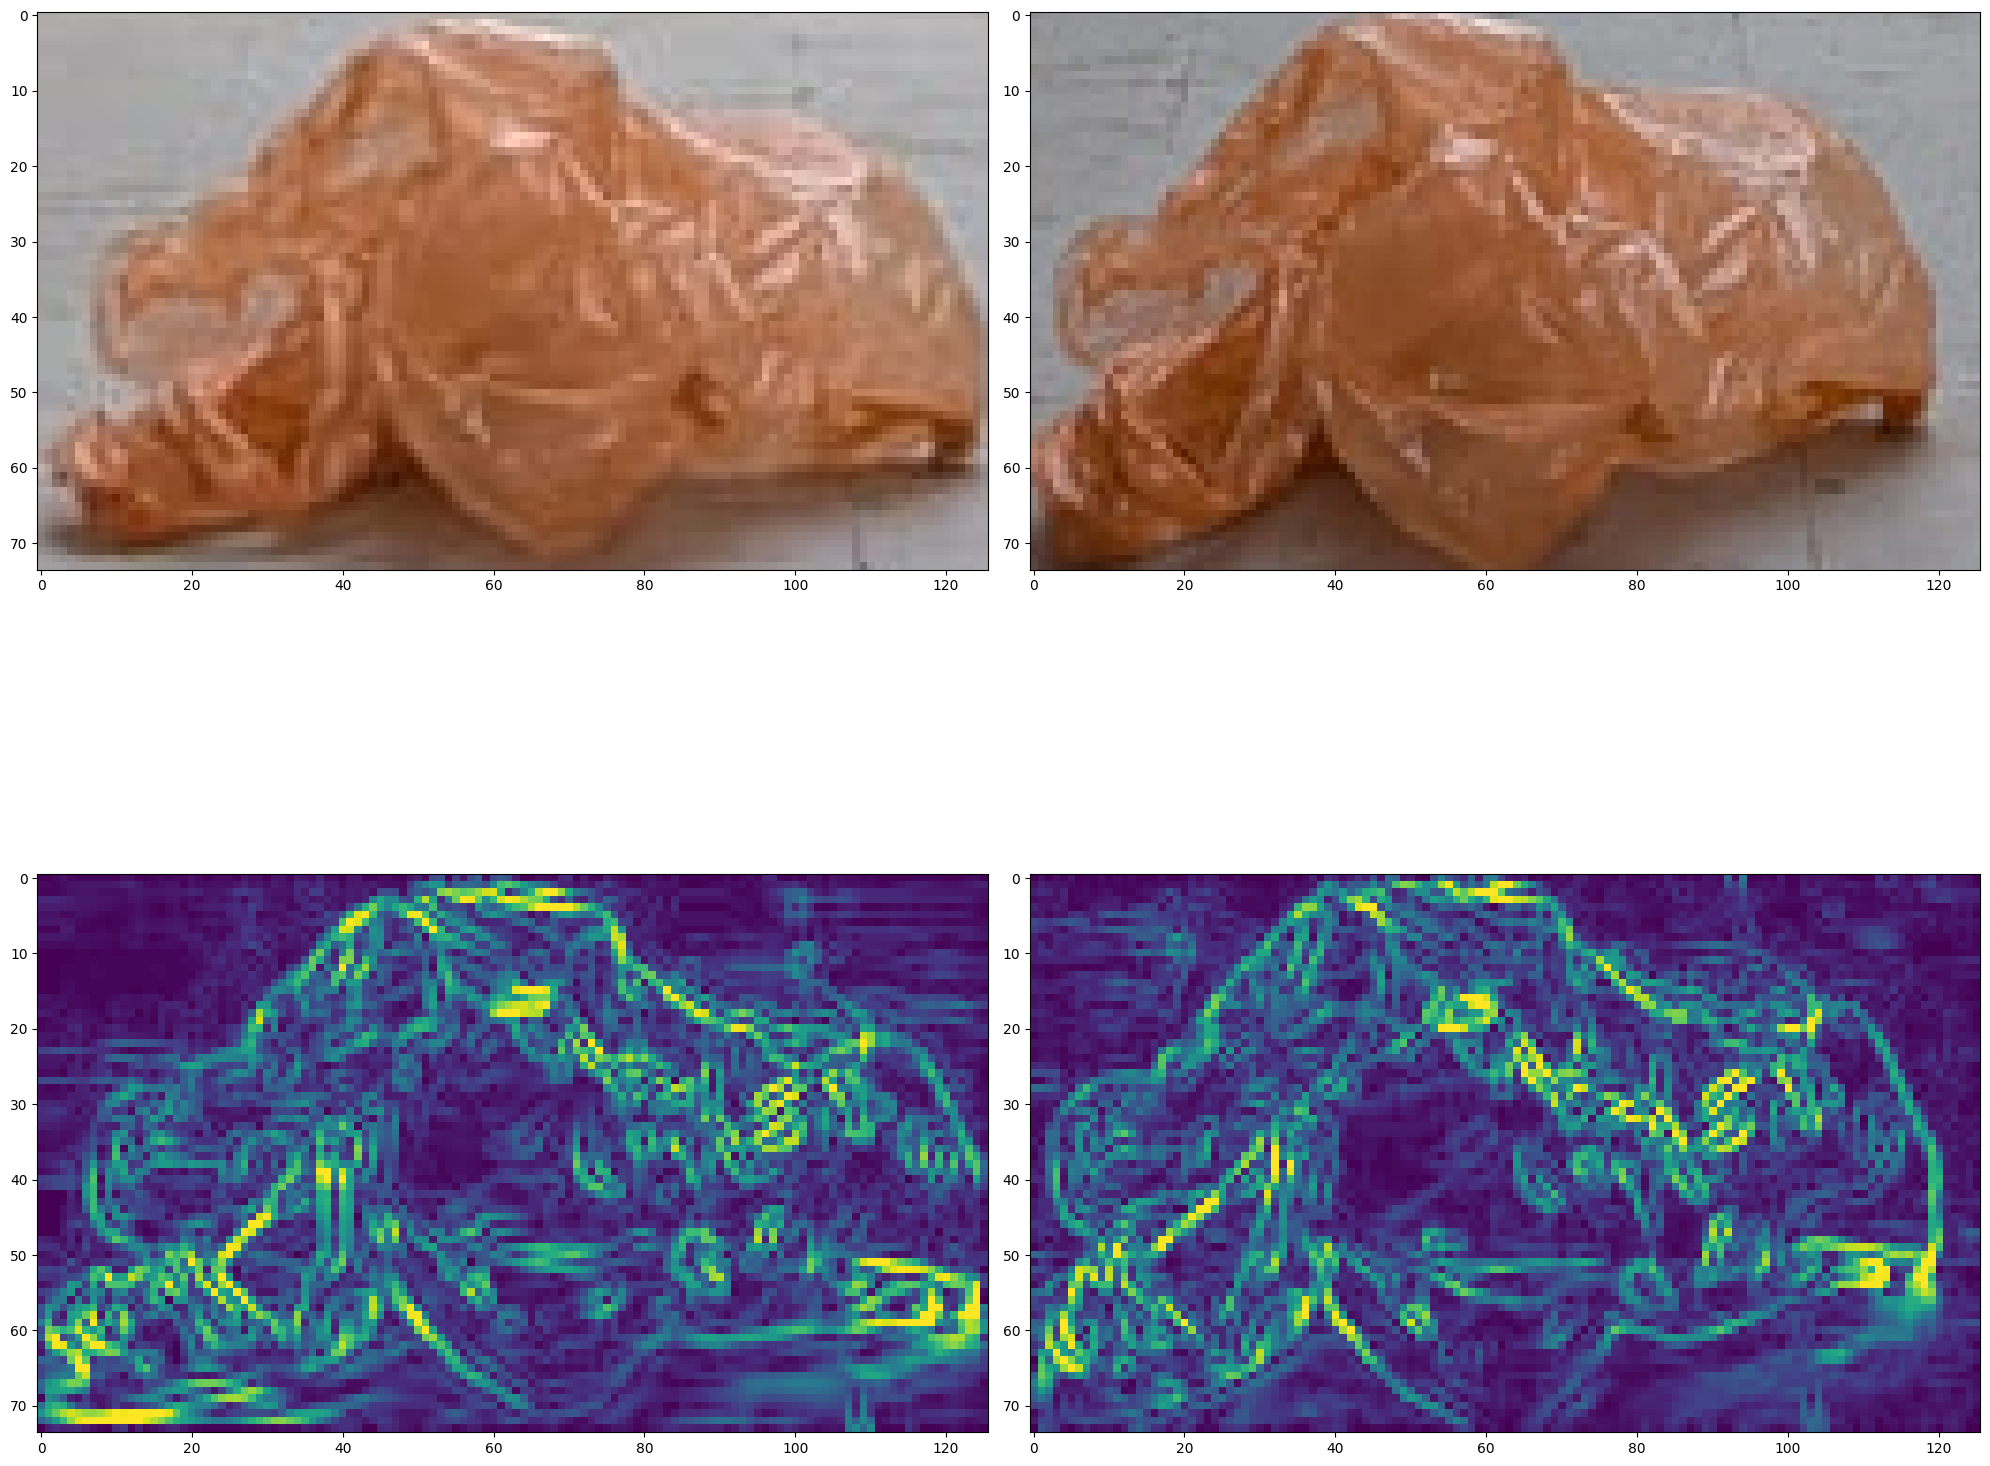

In [35]:
show([
    far[far_bbox], near_rsz[far_bbox],
    far[far_bbox].sobel(), near_rsz[far_bbox].sobel(),
])

figsize (20, 20)


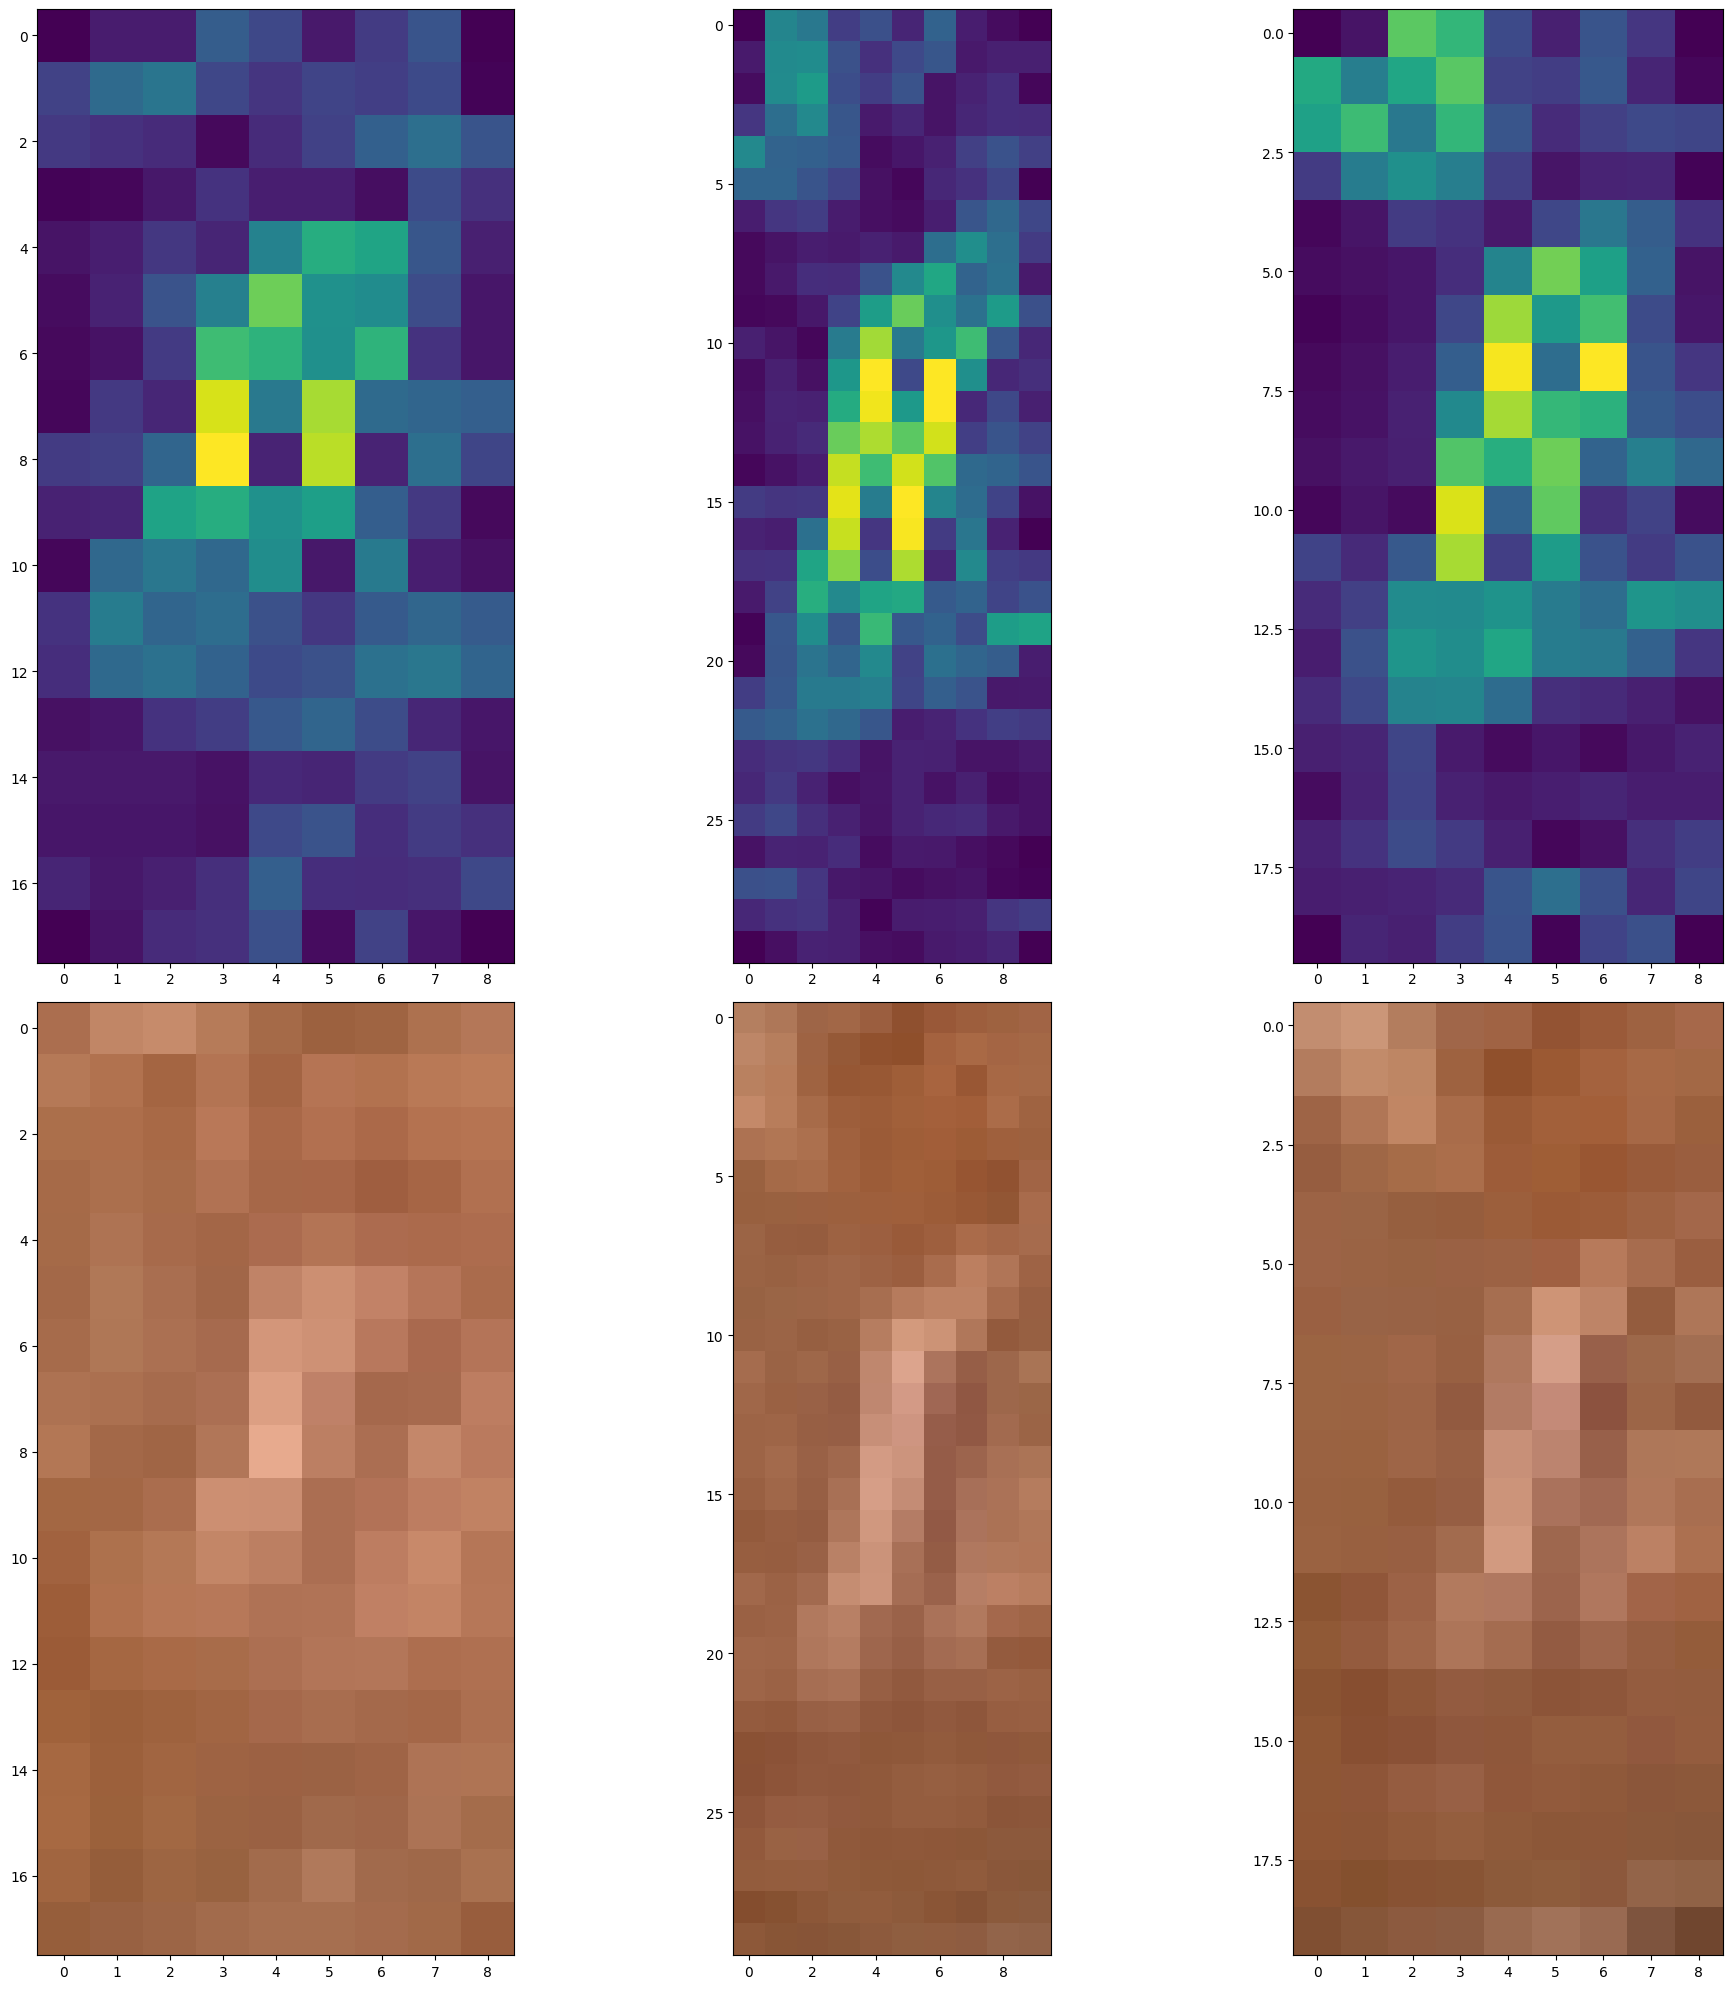

In [29]:
near_high_res = near[near_bbox]
near_high_res_roi = near_high_res[65:95, 142:152]
far_high_res = far[far_bbox]
far_high_res_roi = far_high_res[40:58, 92:101]
near_rsz_roi = near_rsz[far_bbox][40:60, 86:95]

show([
    far_high_res_roi.sobel(), near_high_res_roi.sobel(), near_rsz_roi.sobel(),
    far_high_res_roi, near_high_res_roi, near_rsz_roi,
], ncols=3)

In [30]:

def _gray(rgb):
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

far_line, near_line, near_rsz_line = _gray(far_high_res_roi.rgb)[8], _gray(near_high_res_roi.rgb)[14], _gray(near_rsz_roi.rgb)[10]



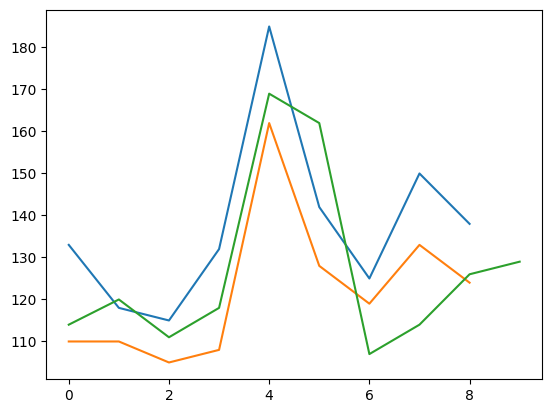

In [31]:
plt.plot(far_line)
plt.plot(near_rsz_line)
plt.plot(near_line)

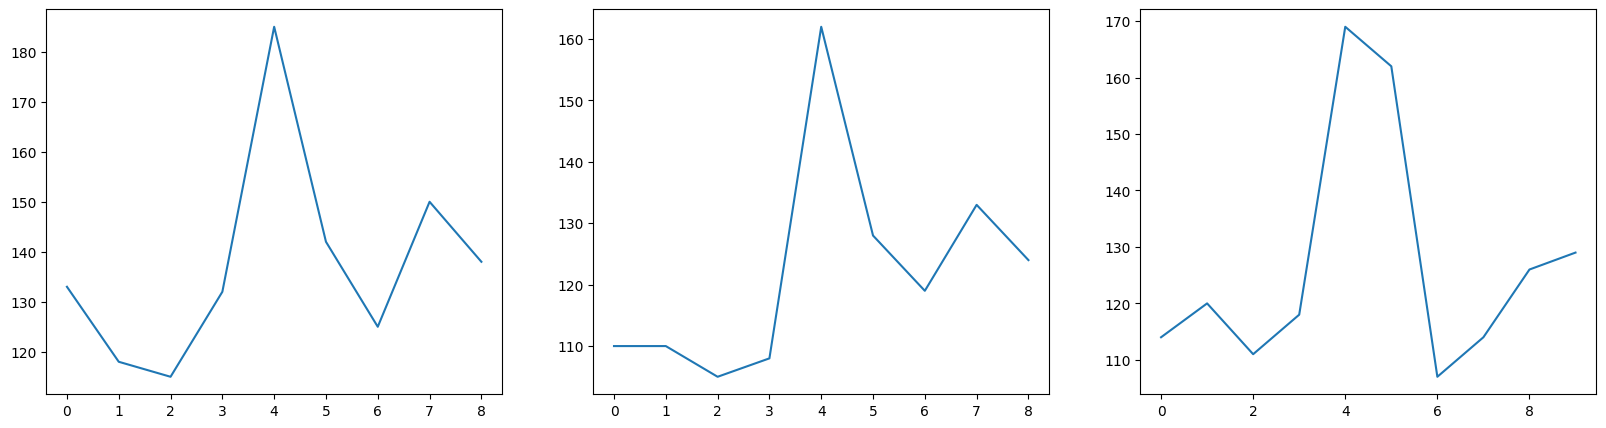

In [33]:
_, axs = plt.subplots(1, 3, figsize=(20,5))

axs[0].plot(far_line)
axs[1].plot(near_rsz_line)
axs[2].plot(near_line)
plt.show()

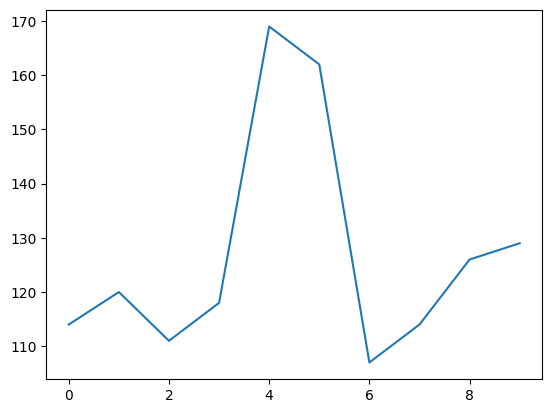

In [149]:
plt.plot(near_line)

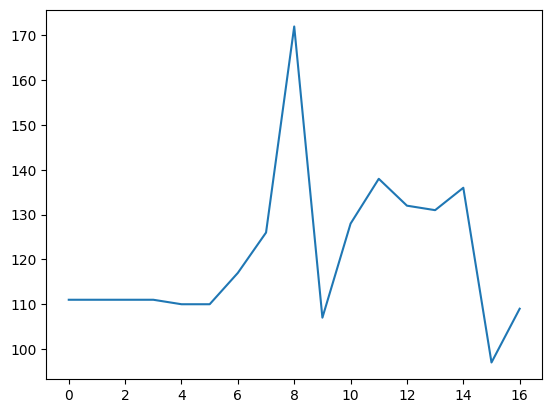

In [150]:
plt.plot(near_rsz_line)

In [100]:
np.min(far_high_res_roi.rgb), np.min(near_high_res_roi.rgb), np.min(near_rsz_roi.rgb)

(np.uint8(55), np.uint8(49), np.uint8(50))

In [101]:
np.max(far_high_res_roi.rgb), np.max(near_high_res_roi.rgb), np.max(near_rsz_roi.rgb)

(np.uint8(231), np.uint8(220), np.uint8(214))

If we look here, it’s checking the rate of change—the difference between the pixels below and the pixels above for vertical changes. I don’t see especially bright colors in the near image compared to the far image.

I think that’s because the illumination hasn’t changed. In the near image, the range between the brightest and dimmest pixels is larger than in the far image.  
I'm currently focusing only on the brightness intensity of edges—basically the points where edges form. These change, but the band between brightness shouldn't change; only the number of pixels covering them does. I'll have to confirm this first. I need two equal parts from both places and I need to see what the maximas are in those places.   
I'll pick the werid almond shaped thing in the right side  

figsize (10, 10)


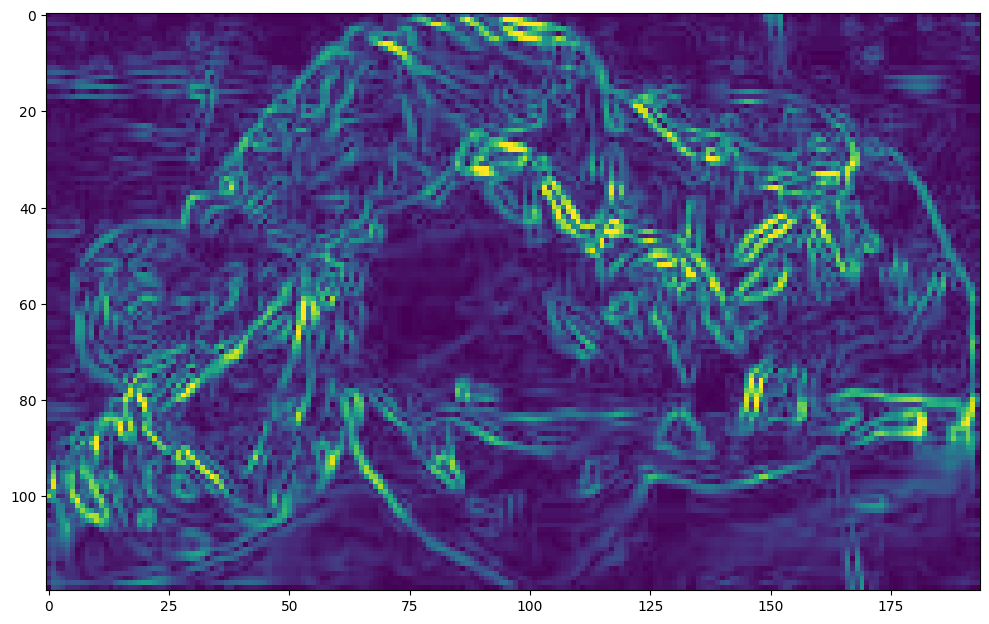

In [36]:
# _, ax = plt.subplots(1, 1, figsize=(15,15))
show([sobel(near[near_bbox].rgb)[2]], ncols=1)
# plt.imshow()

The intensity of edges is a lot more stretched in the original than the resized one. The resized one is actually blurring the highest points, which is not very useful.   

figsize (20, 20)


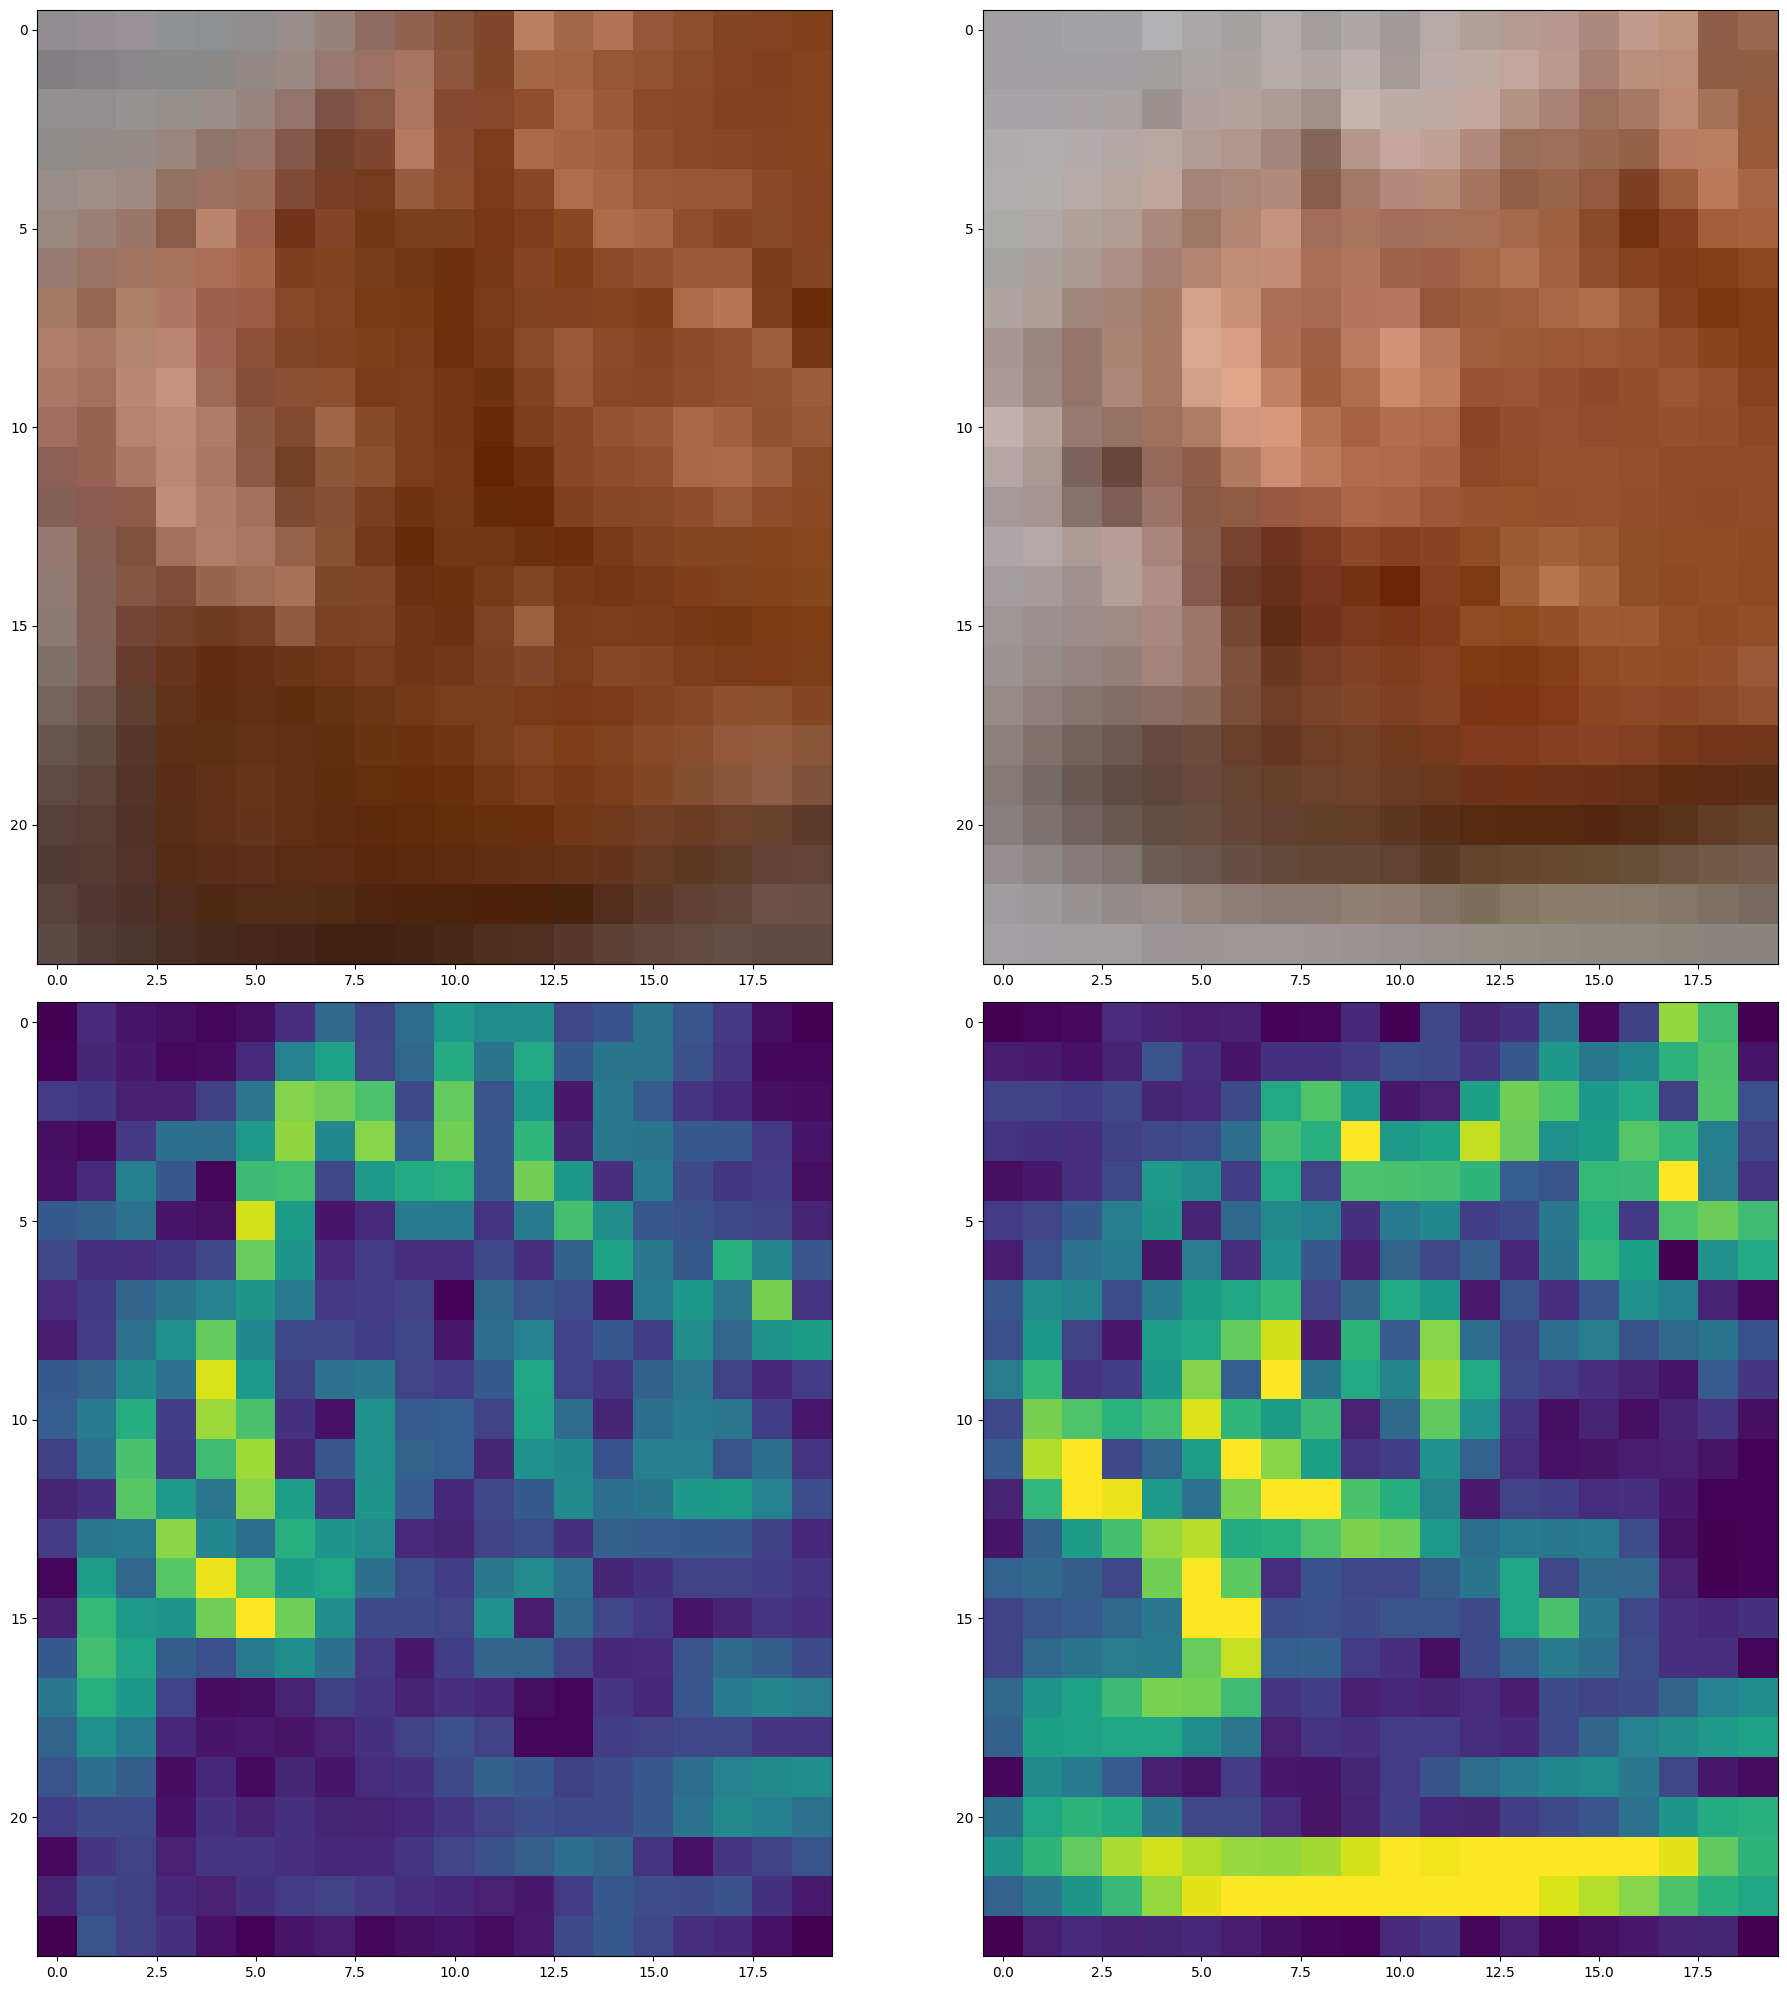

In [41]:
narea = near_rsz[far_bbox][50:, :20]
farea = far[far_bbox][50:, :20]

show([
    narea, farea,
    sobel(narea.rgb)[2], sobel(farea.rgb)[2]
])

will resize shape (160, 261, 3) to (100, 170, 3)
will resize shape (160, 261, 3) to (100, 170, 3)
figsize (30, 30)


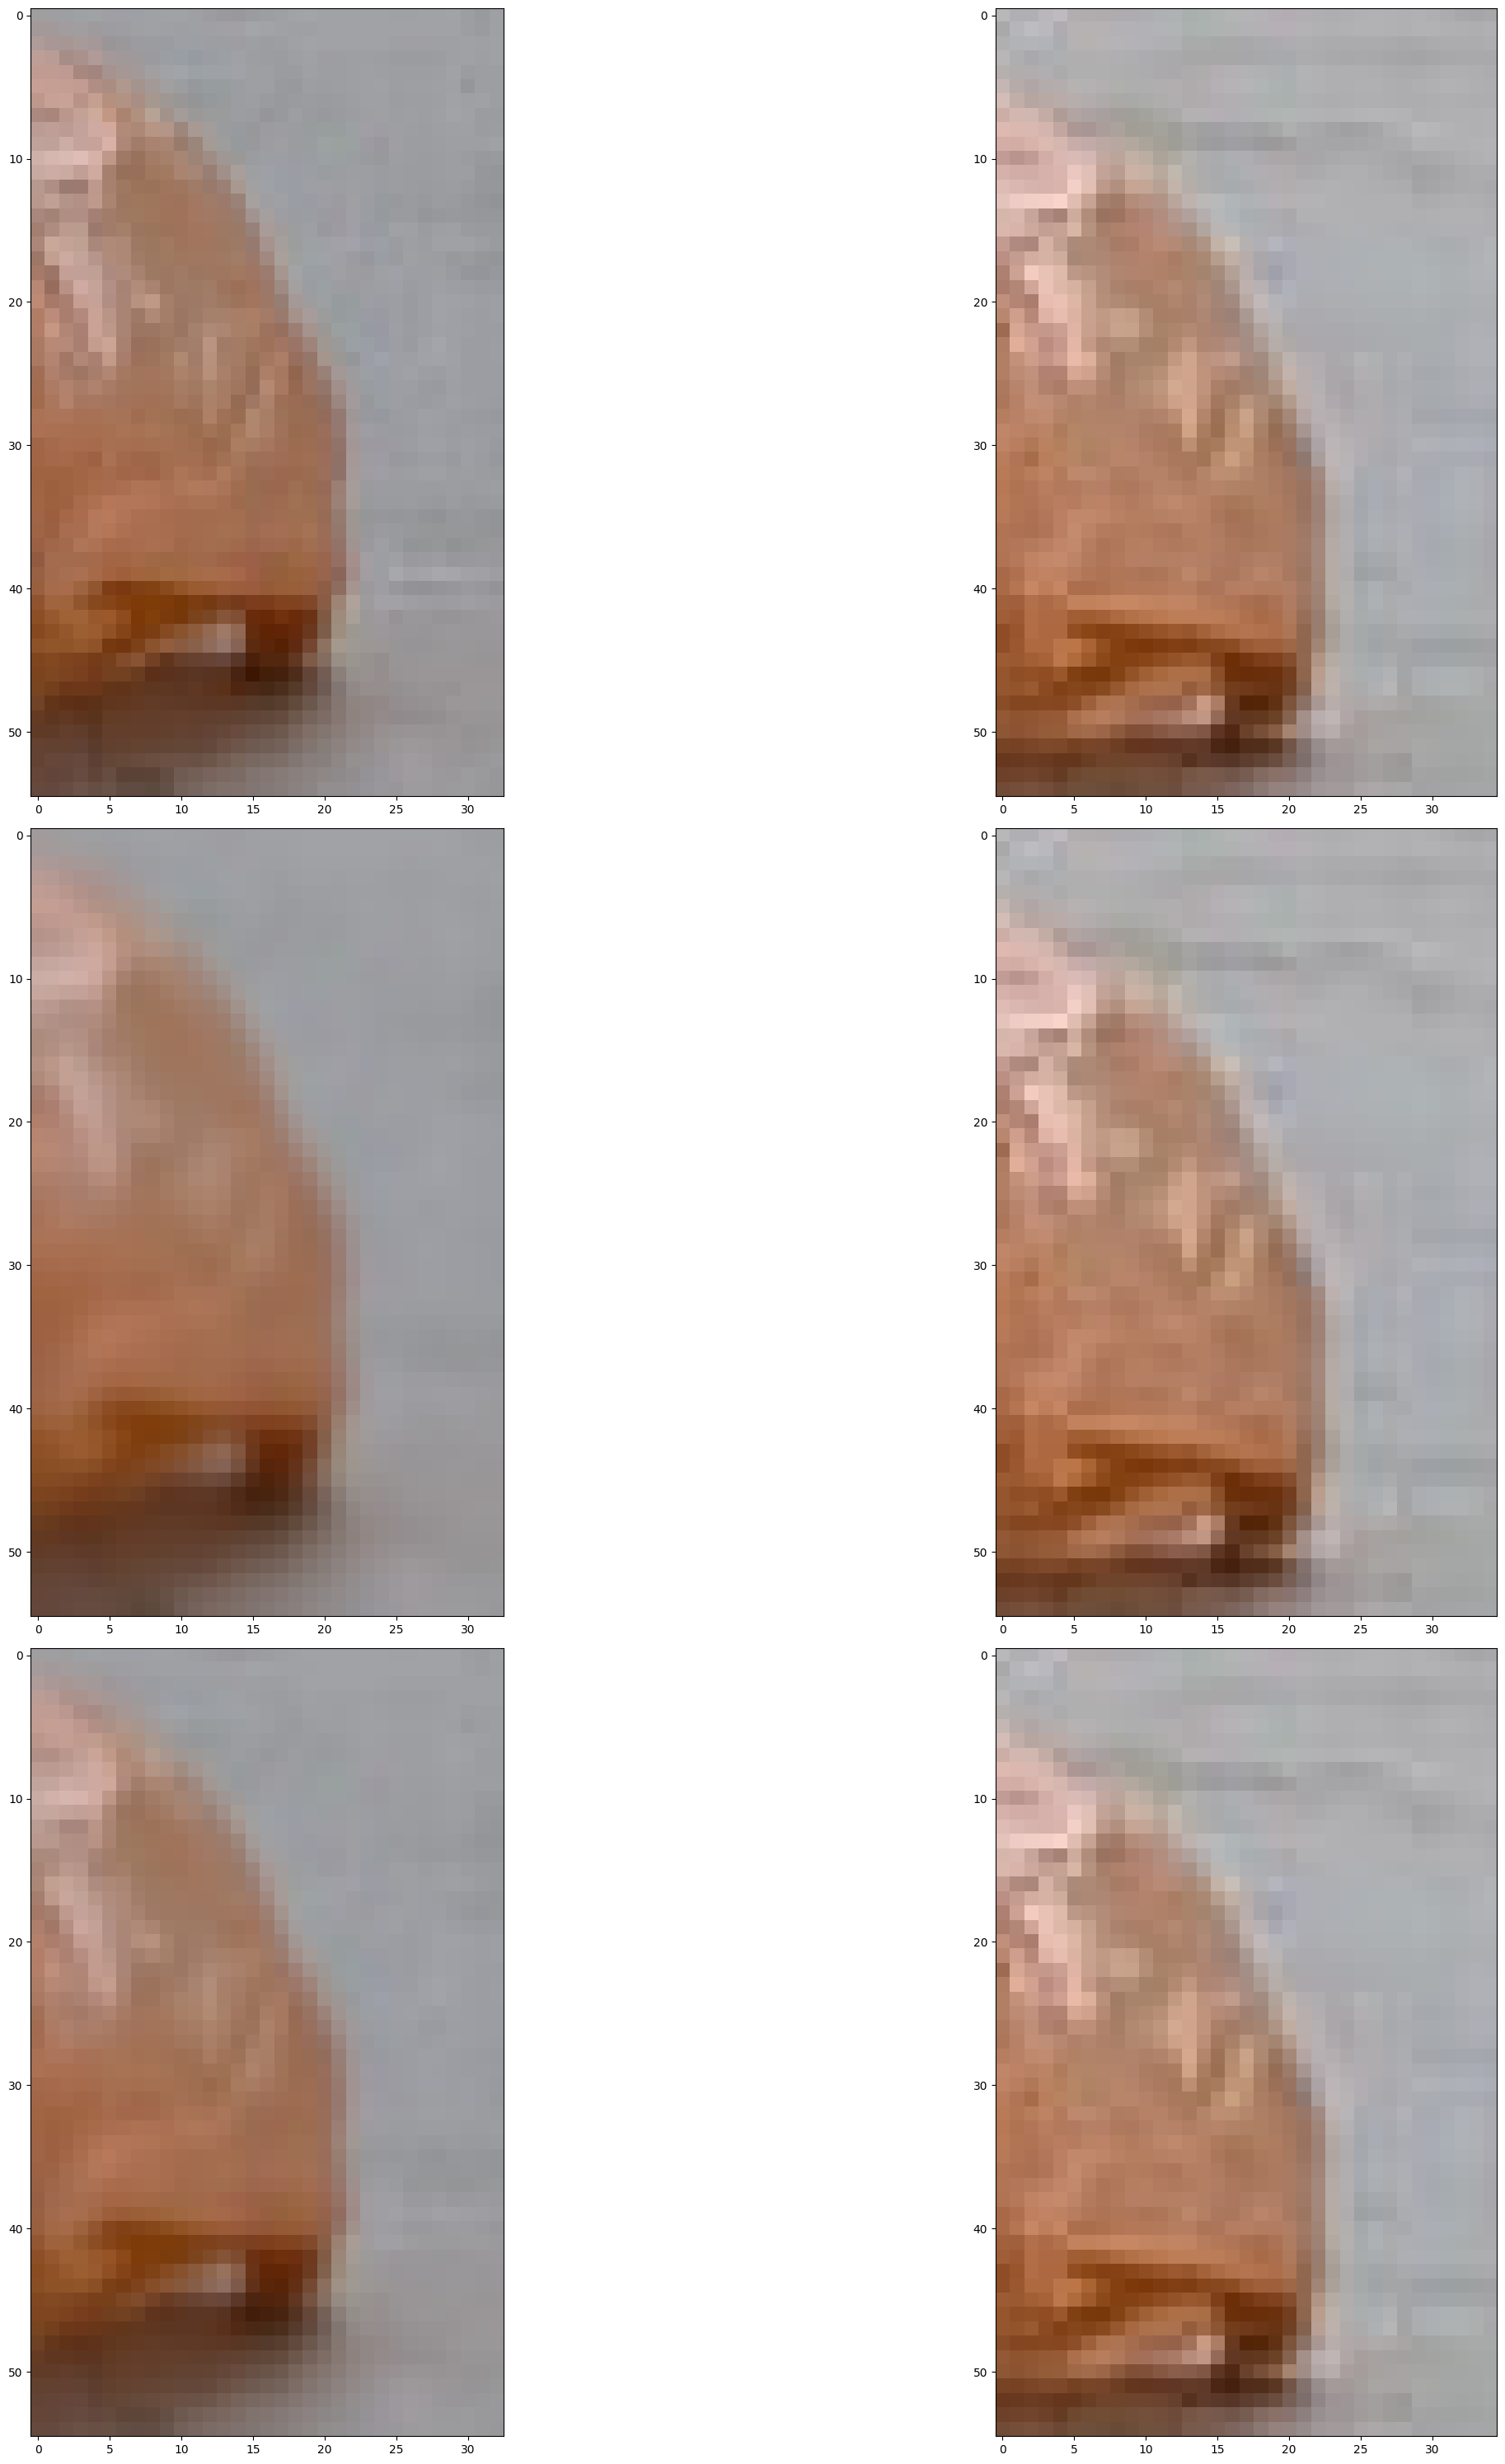

In [33]:
near_edge = near_rsz[20:75, 120:-10]
near_edge_area = near_rsz_area[20:75, 120:-10]
far_edge = far[20:75, 125:-10]

def _get_bbf_edge():
    near = c[700:1120, 380:820]
    near_rgb = cv2.GaussianBlur(near.rgb, (3,3), 1, sigmaY=1)
    near = ImageAndDist.clone_with_diff_rgb(near, near_rgb)
    near_bbox = BBox(y0=120, y1=240, x0=110, x1=304)
    far = x[700:800, 430:600]
    far_bbox = BBox(y0=11, y1=85, x0=22, x1=148)
    near_rsz = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_LINEAR, "h")
    near_rsz_area = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_AREA, "h")
    near_edge = near_rsz[20:75, 120:-10]
    near_edge_area = near_rsz_area[20:75, 120:-10]
    far_edge = far[20:75, 125:-10]
    return near_edge_area, near

bbf_near_edge, bbf_near = _get_bbf_edge()

show([
    near_edge_area, far_edge,
    cv2.GaussianBlur(near_edge_area.rgb, (3,3), 1, sigmaY=1), far_edge,
    bbf_near_edge, far_edge
], ncols=2)

In [25]:
def subtract_imgs(exp1, exp2):
    exp1 = exp1.astype(np.int16)
    exp2 = exp2.astype(np.int16)

    sub =  exp1 -  exp2
    sub = sub - np.min(sub)
    sub = np.clip(sub, 0, 255)

    return sub

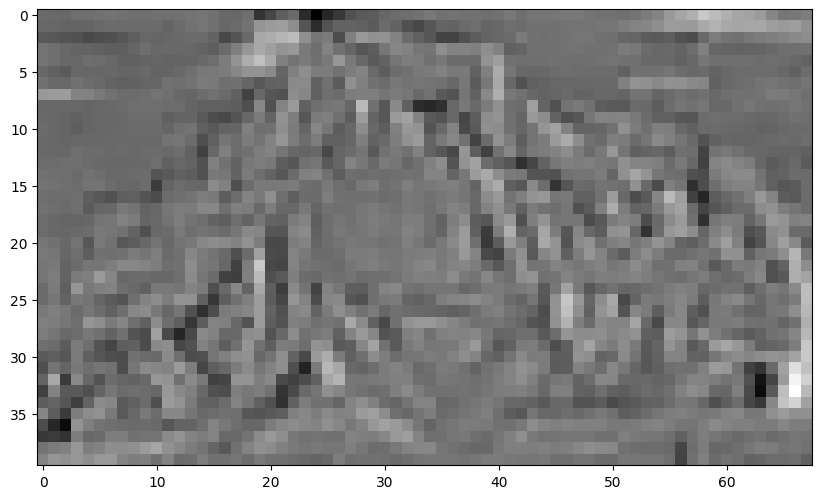

In [20]:
exp1 = near_rsz[far_bbox].rgb
exp2 = far[far_bbox].rgb

exp1 = cv2.cvtColor(exp1, cv2.COLOR_RGB2GRAY).astype(np.int16)
exp2 = cv2.cvtColor(exp2, cv2.COLOR_RGB2GRAY).astype(np.int16)

sub =  exp1 -  exp2

sub = sub - np.min(sub)
sub = np.clip(sub, 0, 255)

_, ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(sub, cmap="gray")
plt.show()
# plt.imshow(sub, cmap="gray")

figsize (10, 10)


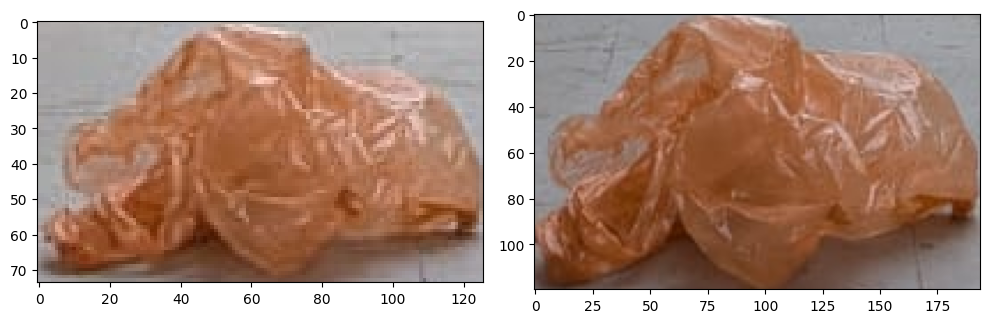

In [37]:
show([far[far_bbox], near[near_bbox]])

figsize (10, 10)


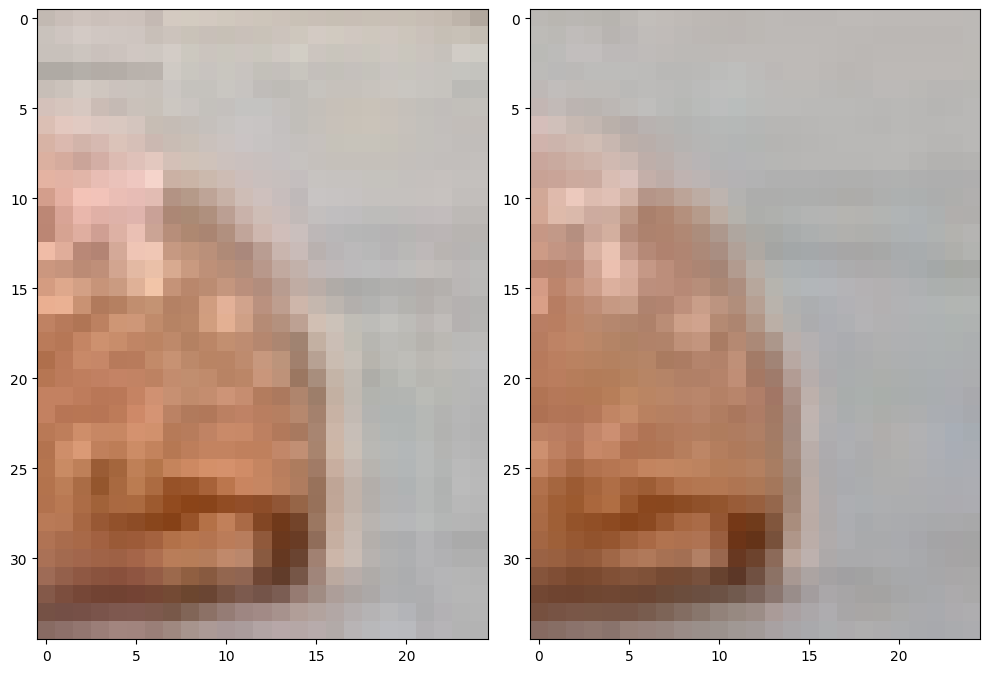

In [22]:
far_edge = far[35:70, 85:110]
near_edge = near_rsz[35:70, 85:110]

# def _get_bbf_edge():
#     pass

# bbf_near_edge, bbf_near = _get_bbf_edge()

show([
    far_edge, near_edge,
    # cv2.GaussianBlur(near_edge.rgb, (3,3), 1, sigmaY=1), far_edge,
    # bbf_near_edge, far_edge
], ncols=2)

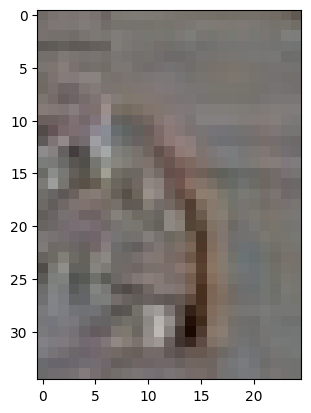

In [ ]:
plt.imshow(subtract_imgs(far_edge.rgb, near_edge.rgb))

I need to work on some examples first to figure out how to do interpolation.   
The first technique is taking an area of interest and doing multiple points in that area of interest. Current techniques do single points given an area of interest.  
There are two parts. we can get all intensity shifts (the frequency can fully be captured). Or we don't. Current examples I have are the ones where intensity shifts are captured generally fully. I will take a look at the cases where full frequency cant be captured later.  

I'm not concerned on whether the image is visually appealing. I just want to recreate a distant image from a nearer image as faithfully as I can.  
Observations:
- Intensity range is not preserved if you do linear interpolation and friends. They average stuff out
- Edges are smoothened, the image looses contrast

Since the intensity range is not preserved, the image looks flat (darkers are less dark, brighters are less bright).   

One of the strategies I came up with for intensity preservation is by selecting the pixels in this order for a region of interest
`[max[0], min[0], max[1], min[1], ...]` and so on (`max[k]` is the `kth` max pixel).  

This can fix the intensity range issue, but we are also now picking pixels randomly. (ignoring noise for now).   
If you have an intensity graph which curves, then we want pixels on both sides of the maxima (ideally the maxima is picked first, then the minima of left, then the minima on right). This is basic frequency sampling, it might be useful to find algorithm for this.  